# Multimodal House Price — Fusion Notebook

Combines:
- **Tabular model**: sklearn OOF ensemble (RF + ET + LGBM)
- **Image model**: CLIP ViT-B/32 → MLP

Two fusion levels provided:
1. `Stage 1` — Prediction blending (simplest, great baseline)
2. `Stage 2` — Feature-level fusion MLP (better, recommended for final model)


In [87]:
# ── Imports ────────────────────────────────────────────────────────────────
import os, random, warnings
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

import clip

from sklearn.model_selection import train_test_split, KFold
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.base import clone
from lightgbm import LGBMRegressor

import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
RANDOM_STATE = 42

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cpu


## 1. Load & Align Both Datasets

**The core rule**: `house_id` is the single source of truth.
We build one master DataFrame that has both tabular features AND image paths.
Everything — cleaning, splitting, training — flows from this one table.

In [62]:
# -- Paths -----------------------------------------------------------------
TABULAR_CSV = Path('../data/satilir_model_base_with_house_id.csv')
IMAGE_CSV   = Path('../data/satilir_id_price_folder.csv')

RAW_LOC_ENCODED = Path('../data/satilir_location_encoded_oof_v6.csv')
BRIDGE_CSV      = Path('../data/satilir_tabular_image_bridge.csv')
LOC_ENCODED     = Path('../data/satilir_location_encoded_oof_v6_with_house_id.csv')

PHOTO_ROOT_CANDIDATES = [
    Path('../satilir_photos/satilir_photos'),
    Path('../satilir_photos'),
]
PHOTOS_DIR = next((p for p in PHOTO_ROOT_CANDIDATES if p.exists()), PHOTO_ROOT_CANDIDATES[0])

OUTPUT_DIR = Path('../models/multimodal')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

VALID_EXT  = {'.jpg', '.jpeg', '.png', '.webp', '.bmp'}
MAX_IMAGES = 20
IMG_SIZE   = 224

print('Tabular CSV:', TABULAR_CSV)
print('Image CSV  :', IMAGE_CSV)
print('Photos dir :', PHOTOS_DIR.resolve())
print('Raw loc    :', RAW_LOC_ENCODED, '(exists=' + str(RAW_LOC_ENCODED.exists()) + ')')
print('Bridge CSV :', BRIDGE_CSV, '(exists=' + str(BRIDGE_CSV.exists()) + ')')
print('Loc file   :', LOC_ENCODED, '(exists=' + str(LOC_ENCODED.exists()) + ')')

Tabular CSV: ..\data\satilir_model_base_with_house_id.csv
Image CSV  : ..\data\satilir_id_price_folder.csv
Photos dir : E:\Coding\ai_project\satilir_photos\satilir_photos
Raw loc    : ..\data\satilir_location_encoded_oof_v6.csv (exists=True)
Bridge CSV : ..\data\satilir_tabular_image_bridge.csv (exists=True)
Loc file   : ..\data\satilir_location_encoded_oof_v6_with_house_id.csv (exists=False)


In [63]:
# -- Load tabular data -------------------------------------------------------
df_tab = pd.read_csv(TABULAR_CSV)
print('Tabular shape:', df_tab.shape)
print('Tabular columns (first 10):', df_tab.columns[:10].tolist())

assert 'house_id' in df_tab.columns, (
    "'house_id' not found in tabular CSV. "
    "Use satilir_model_base_with_house_id.csv or regenerate the tabular export with house_id included."
)

df_tab['house_id'] = pd.to_numeric(df_tab['house_id'], errors='coerce').astype('Int64')
df_tab = df_tab.dropna(subset=['house_id']).reset_index(drop=True)
print('Tabular rows after house_id cleanup:', len(df_tab))

Tabular shape: (4416, 59)
Tabular columns (first 10): ['yes_no_binary__has_document', 'yes_no_binary__avtodayanacaq', 'yes_no_binary__balkon', 'yes_no_binary__duzelme', 'yes_no_binary__esyali', 'yes_no_binary__hovuz', 'yes_no_binary__internet', 'yes_no_binary__isiq', 'yes_no_binary__kabel_tv', 'yes_no_binary__kombi']
Tabular rows after house_id cleanup: 4412


In [64]:
# ── Load image CSV & get image paths ──────────────────────────────────────
df_img = pd.read_csv(IMAGE_CSV)
df_img['house_id'] = pd.to_numeric(df_img['house_id'], errors='coerce').astype('Int64')
df_img['price']    = pd.to_numeric(df_img['price'], errors='coerce')
df_img = df_img.dropna(subset=['house_id', 'price', 'image_folder_name']).reset_index(drop=True)

def get_image_paths(folder_name):
    folder = PHOTOS_DIR / str(folder_name)
    if not folder.exists():
        return []
    return [f for f in sorted(folder.iterdir()) if f.suffix.lower() in VALID_EXT]

df_img['img_paths'] = df_img['image_folder_name'].apply(get_image_paths)
df_img['n_images']  = df_img['img_paths'].apply(len)
df_img = df_img[df_img['n_images'] >= 1].reset_index(drop=True)

print('Image CSV shape after filtering:', df_img.shape)

Image CSV shape after filtering: (4412, 8)


In [65]:
# ── ALIGNMENT: Inner join on house_id ─────────────────────────────────────
# This is the key step. Only houses that exist in BOTH datasets are kept.
# Any row cleaned/dropped in tabular automatically disappears here too.

# Columns to bring from image CSV (don't bring 'price' if tabular already has it)
img_cols = ['house_id', 'image_folder_name', 'img_paths', 'n_images']
if 'price' not in df_tab.columns:
    img_cols.append('price')   # use price from image CSV if tabular doesn't have it

df = df_tab.merge(df_img[img_cols], on='house_id', how='inner')
df = df.reset_index(drop=True)

print(f'Tabular rows  : {len(df_tab):,}')
print(f'Image rows    : {len(df_img):,}')
print(f'Merged rows   : {len(df):,}  ← only houses present in both')
print(f'Dropped (tab) : {len(df_tab) - len(df):,}  (no matching image)')
print(f'Dropped (img) : {len(df_img) - len(df):,}  (no matching tabular data)')

Tabular rows  : 4,412
Image rows    : 4,412
Merged rows   : 4,412  ← only houses present in both
Dropped (tab) : 0  (no matching image)
Dropped (img) : 0  (no matching tabular data)


In [66]:
# -- Deterministic location-encoded export + merge --------------------------
# Build a house_id-keyed location file from model_base_idx, then merge only new cols.
if RAW_LOC_ENCODED.exists() and BRIDGE_CSV.exists():
    try:
        loc_raw = pd.read_csv(RAW_LOC_ENCODED)
        bridge = pd.read_csv(BRIDGE_CSV, usecols=['house_id', 'model_base_idx'])

        bridge['house_id'] = pd.to_numeric(bridge['house_id'], errors='coerce').astype('Int64')
        bridge['model_base_idx'] = pd.to_numeric(bridge['model_base_idx'], errors='coerce').astype('Int64')
        bridge = bridge.dropna(subset=['house_id', 'model_base_idx'])
        bridge = bridge.drop_duplicates(subset=['house_id'], keep='first').reset_index(drop=True)

        valid = bridge[(bridge['model_base_idx'] >= 0) & (bridge['model_base_idx'] < len(loc_raw))].copy()
        invalid = len(bridge) - len(valid)

        loc_cols = [c for c in loc_raw.columns if c not in {'house_id', 'price', 'num__price'}]
        loc_vals = loc_raw.iloc[valid['model_base_idx'].astype(int).values][loc_cols].reset_index(drop=True)
        loc_with_id = pd.concat([valid[['house_id']].reset_index(drop=True), loc_vals], axis=1)
        loc_with_id = loc_with_id.drop_duplicates(subset=['house_id'], keep='first').reset_index(drop=True)

        loc_with_id.to_csv(LOC_ENCODED, index=False)
        print(f'Exported deterministic location file: {LOC_ENCODED}')
        print(f'  rows={len(loc_with_id):,} cols={len(loc_cols):,} invalid_bridge_rows={invalid:,}')
    except Exception as loc_exc:
        print('Failed to build deterministic location export:', str(loc_exc)[:220])
else:
    print('Raw location or bridge file missing; deterministic export not generated.')

if LOC_ENCODED.exists():
    loc_encoded_all = pd.read_csv(LOC_ENCODED)
    print('Location-encoded keyed shape:', loc_encoded_all.shape)

    if 'house_id' in loc_encoded_all.columns:
        loc_encoded_all['house_id'] = pd.to_numeric(loc_encoded_all['house_id'], errors='coerce').astype('Int64')
        loc_encoded_all = loc_encoded_all.dropna(subset=['house_id'])
        loc_encoded_all = loc_encoded_all.drop_duplicates(subset=['house_id'], keep='first').reset_index(drop=True)

        loc_cols_to_add = [c for c in loc_encoded_all.columns if c != 'house_id' and c not in df.columns]
        if loc_cols_to_add:
            df = df.merge(loc_encoded_all[['house_id'] + loc_cols_to_add], on='house_id', how='left')
            match_rate = df[loc_cols_to_add[0]].notna().mean()
            df[loc_cols_to_add] = df[loc_cols_to_add].fillna(0.0)
            print(f'Added {len(loc_cols_to_add)} location columns by house_id merge (match_rate={match_rate:.2%}).')
        else:
            print('No new location columns to add (already present).')
    else:
        print('Keyed location file has no house_id; skipping merge.')
else:
    print('LOC_ENCODED file not found; skipping extra location merge.')

df = df.reset_index(drop=True)
print('Final merged shape:', df.shape)

Exported deterministic location file: ..\data\satilir_location_encoded_oof_v6_with_house_id.csv
  rows=4,412 cols=10 invalid_bridge_rows=0
Location-encoded keyed shape: (4412, 11)
Added 10 location columns by house_id merge (match_rate=100.00%).
Final merged shape: (4412, 73)


## 2. One Split — Used for Everything

Split ONCE by `house_id`, then derive all subsets from this split.
Never split tabular and images separately.

In [67]:
# Price column name — adjust if your tabular CSV calls it differently
PRICE_COL = 'num__price' if 'num__price' in df.columns else 'price'

# Filter extreme prices
df = df[df[PRICE_COL] < 10_000_000].reset_index(drop=True)

# Stratified split on price quantile bins
df['price_bin'] = pd.qcut(df[PRICE_COL], q=5, labels=False, duplicates='drop')

all_ids = df['house_id'].unique()
id_to_bin = df.drop_duplicates('house_id').set_index('house_id')['price_bin']

train_ids, temp_ids = train_test_split(
    all_ids, test_size=0.28, random_state=RANDOM_STATE,
    stratify=id_to_bin.loc[all_ids]
)
val_ids, test_ids = train_test_split(temp_ids, test_size=0.50, random_state=RANDOM_STATE)

train_df = df[df['house_id'].isin(train_ids)].copy().reset_index(drop=True)
val_df   = df[df['house_id'].isin(val_ids)].copy().reset_index(drop=True)
test_df  = df[df['house_id'].isin(test_ids)].copy().reset_index(drop=True)

# Winsorize price on train only
price_cap = float(train_df[PRICE_COL].quantile(0.98))
train_df = train_df[train_df[PRICE_COL] <= price_cap].reset_index(drop=True)

print(f'Train: {len(train_df):,}  Val: {len(val_df):,}  Test: {len(test_df):,}')

Train: 3,112  Val: 618  Test: 618


## 3. Tabular Model — Get OOF Predictions

We train the sklearn ensemble and get **predictions for every house**.
These predictions become one of the inputs to the fusion layer.

In [68]:
# ── Define tabular feature columns ────────────────────────────────────────
# Exclude non-feature columns from training
EXCLUDE_COLS = {'house_id', PRICE_COL, 'price_bin', 'image_folder_name',
                'img_paths', 'n_images', 'price'}

TAB_FEATURES = [c for c in train_df.columns if c not in EXCLUDE_COLS
                and train_df[c].dtype in [np.float64, np.float32, np.int64, np.int32, float, int]]

print(f'Tabular feature count: {len(TAB_FEATURES)}')

X_train_tab = train_df[TAB_FEATURES].values
X_val_tab   = val_df[TAB_FEATURES].values
X_test_tab  = test_df[TAB_FEATURES].values

y_train = train_df[PRICE_COL].values.astype(float)
y_val   = val_df[PRICE_COL].values.astype(float)
y_test  = test_df[PRICE_COL].values.astype(float)

Tabular feature count: 64


In [11]:
# ── Train tabular ensemble — same setup as your original notebook ──────────
# (Paste your best_rf_loc_params here after running your tabular notebook)
best_rf_params = {
    'n_estimators': 2000,
    'max_depth': None,
    'max_features': 0.7,
    'min_samples_split': 4,
    'min_samples_leaf': 1,
    'bootstrap': True,
}

base_models = {
    'rf': RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1, **best_rf_params),
    'et': ExtraTreesRegressor(
        n_estimators=2200, max_depth=None, max_features=0.7,
        min_samples_split=2, min_samples_leaf=1, bootstrap=False,
        random_state=RANDOM_STATE, n_jobs=-1,
    ),
    'lgbm': LGBMRegressor(
        n_estimators=1600, learning_rate=0.03, num_leaves=63,
        subsample=0.85, colsample_bytree=0.8, min_child_samples=20,
        reg_alpha=0.1, reg_lambda=1.0, random_state=RANDOM_STATE,
        n_jobs=-1, verbose=-1,
    ),
}

# Fit on full train set
fitted_tab = {}
for name, model in base_models.items():
    print(f'Fitting {name}...')
    m = clone(model)
    m.fit(X_train_tab, y_train)
    fitted_tab[name] = m

# Blend (use weights from your original notebook, or 0.5/0.5 as default)
W_LEFT, W_RIGHT, LEFT, RIGHT = 0.5, 0.5, 'rf', 'lgbm'  # ← paste your best_combo here

def tab_predict(X):
    return np.clip(
        W_LEFT  * fitted_tab[LEFT].predict(X) +
        W_RIGHT * fitted_tab[RIGHT].predict(X),
        0, None
    )

tab_pred_train = tab_predict(X_train_tab)
tab_pred_val   = tab_predict(X_val_tab)
tab_pred_test  = tab_predict(X_test_tab)

print(f'Tabular val R2  : {r2_score(y_val, tab_pred_val):.4f}')
print(f'Tabular val MAE : {mean_absolute_error(y_val, tab_pred_val):,.0f}')

Fitting rf...
Fitting et...
Fitting lgbm...
Tabular val R2  : 0.7641
Tabular val MAE : 28,320


## 4. Image Model — Extract CLIP Embeddings

Same as your image notebook — pre-extract once, cache to disk.

In [12]:
# ── Load CLIP ──────────────────────────────────────────────────────────────
clip_model, _ = clip.load('ViT-B/32', device=device)
clip_model     = clip_model.float().eval()
CLIP_DIM       = clip_model.visual.output_dim  # 512

for param in clip_model.parameters():
    param.requires_grad = False

tfm = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.48145466, 0.4578275, 0.40821073),
        std =(0.26862954, 0.26130258, 0.27577711),
    ),
])
print(f'CLIP loaded. Each house → {CLIP_DIM}-d embedding.')

100%|███████████████████████████████████████| 338M/338M [00:45<00:00, 7.76MiB/s]


CLIP loaded. Each house → 512-d embedding.


In [13]:
EMBED_CACHE = OUTPUT_DIR / 'multimodal_embeddings.pt'

@torch.no_grad()
def embed_house(img_paths):
    tensors = []
    for path in img_paths[:MAX_IMAGES]:
        try:
            tensors.append(tfm(Image.open(path).convert('RGB')))
        except Exception:
            continue
    if not tensors:
        return torch.zeros(CLIP_DIM)
    batch = torch.stack(tensors).to(device)
    embs  = clip_model.encode_image(batch)
    embs  = F.normalize(embs.float(), dim=-1)
    return embs.mean(dim=0).cpu()

if EMBED_CACHE.exists():
    embeddings = torch.load(EMBED_CACHE)
    print(f'Loaded {len(embeddings):,} cached embeddings.')
else:
    print('Extracting embeddings (runs once)...')
    embeddings = {}
    for _, row in tqdm(df.iterrows(), total=len(df), desc='Embedding'):
        hid = int(row['house_id'])
        if hid not in embeddings:   # df may have duplicate house_ids
            embeddings[hid] = embed_house(row['img_paths'])
    torch.save(embeddings, EMBED_CACHE)
    print(f'Done. {len(embeddings):,} embeddings saved.')

Extracting embeddings (runs once)...


Embedding: 100%|██████████| 4412/4412 [33:12<00:00,  2.21it/s]


Done. 4,412 embeddings saved.


## 5A. Stage 1 — Prediction Blending (Simple Baseline)

Train the image MLP on the same split, get predictions, then blend with tabular predictions.
This works well and is very interpretable.

```
Tabular ensemble → pred_tab  ─┐
                               ├→ α·pred_tab + (1-α)·pred_img → final price
CLIP → MLP       → pred_img  ─┘
```

In [14]:
# ── Log-normalize target (same as your image notebook) ────────────────────
log_prices = np.log1p(y_train)
Y_MEAN = float(log_prices.mean())
Y_STD  = float(log_prices.std()) + 1e-8

def to_price(x_norm):
    return np.expm1(np.clip(x_norm * Y_STD + Y_MEAN, 6.0, 16.5))

def norm_price(price):
    return (np.log1p(price) - Y_MEAN) / Y_STD


# ── Image-only Dataset ─────────────────────────────────────────────────────
class ImageDataset(Dataset):
    def __init__(self, dataframe, price_col=PRICE_COL):
        self.df = dataframe.reset_index(drop=True)
        self.price_col = price_col

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        emb = embeddings[int(row['house_id'])]  # [512]
        target = torch.tensor(norm_price(float(row[self.price_col])), dtype=torch.float32)
        return emb, target


BATCH_SIZE = 64
img_train_loader = DataLoader(ImageDataset(train_df), batch_size=BATCH_SIZE, shuffle=True)
img_val_loader   = DataLoader(ImageDataset(val_df),   batch_size=BATCH_SIZE, shuffle=False)
img_test_loader  = DataLoader(ImageDataset(test_df),  batch_size=BATCH_SIZE, shuffle=False)

In [15]:
# ── Train image MLP (same as your original image notebook) ────────────────
EPOCHS  = 100
LR      = 3e-4
PATIENCE = 10

img_model = nn.Sequential(
    nn.LayerNorm(CLIP_DIM),
    nn.Linear(CLIP_DIM, 512), nn.GELU(), nn.Dropout(0.3),
    nn.Linear(512, 128),      nn.GELU(), nn.Dropout(0.15),
    nn.Linear(128, 1),
).to(device)

criterion = nn.HuberLoss(delta=0.5)
optimizer = torch.optim.AdamW(img_model.parameters(), lr=LR, weight_decay=1e-2)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=LR, steps_per_epoch=len(img_train_loader), epochs=EPOCHS
)

def mdape(true, pred):
    return float(np.median(np.abs(true - pred) / (true + 1e-8)) * 100)

@torch.no_grad()
def eval_model(model, loader):
    model.eval()
    preds, targets = [], []
    for emb, target in loader:
        p = model(emb.to(device)).squeeze(1)
        preds.append(p.cpu().numpy())
        targets.append(target.numpy())
    return to_price(np.concatenate(preds)), to_price(np.concatenate(targets))


best_mdape, best_weights, no_improve = float('inf'), None, 0
print(f'{"Ep":>4} | {"Loss":>7} | {"Val MAE":>11} | {"MdAPE":>7}')
print('-' * 38)

for epoch in range(1, EPOCHS + 1):
    img_model.train()
    total_loss = 0.0
    for emb, target in img_train_loader:
        emb, target = emb.to(device), target.to(device)
        pred = img_model(emb).squeeze(1)
        loss = criterion(pred, target)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        total_loss += loss.item()
    scheduler.step()

    preds_azn, targets_azn = eval_model(img_model, img_val_loader)
    val_mae   = mean_absolute_error(targets_azn, preds_azn)
    val_mdape = mdape(targets_azn, preds_azn)
    marker = ' '
    if val_mdape < best_mdape:
        best_mdape   = val_mdape
        best_weights = {k: v.clone() for k, v in img_model.state_dict().items()}
        no_improve   = 0; marker = '*'
    else:
        no_improve += 1
    print(f'{marker}{epoch:3d}/{EPOCHS} | {total_loss/len(img_train_loader):.4f} | {val_mae:>11,.0f} | {val_mdape:>6.2f}%')
    if no_improve >= PATIENCE:
        print('Early stop'); break

img_model.load_state_dict(best_weights)
print(f'\nBest val MdAPE (image-only): {best_mdape:.2f}%')

  Ep |    Loss |     Val MAE |   MdAPE
--------------------------------------
*  1/100 | 0.2735 |      69,564 |  38.45%
   2/100 | 0.2698 |      69,021 |  38.68%
*  3/100 | 0.2673 |      68,296 |  38.35%
*  4/100 | 0.2625 |      67,394 |  38.20%
*  5/100 | 0.2587 |      66,632 |  37.59%
*  6/100 | 0.2531 |      65,481 |  36.76%
*  7/100 | 0.2503 |      64,656 |  36.49%
*  8/100 | 0.2448 |      63,293 |  35.29%
*  9/100 | 0.2409 |      61,983 |  34.11%
* 10/100 | 0.2379 |      61,297 |  33.71%
* 11/100 | 0.2341 |      60,406 |  32.16%
* 12/100 | 0.2306 |      60,335 |  31.76%
* 13/100 | 0.2288 |      59,193 |  30.79%
* 14/100 | 0.2250 |      58,966 |  30.63%
* 15/100 | 0.2240 |      58,168 |  29.72%
* 16/100 | 0.2210 |      57,382 |  29.68%
  17/100 | 0.2183 |      57,587 |  30.02%
  18/100 | 0.2164 |      57,626 |  30.17%
* 19/100 | 0.2173 |      56,172 |  29.28%
* 20/100 | 0.2153 |      55,503 |  29.28%
* 21/100 | 0.2141 |      55,653 |  29.08%
  22/100 | 0.2138 |      55,153 |  29.35

In [16]:
# ── Blend predictions ─────────────────────────────────────────────────────
# Get image model predictions
img_pred_val,  _ = eval_model(img_model, img_val_loader)
img_pred_test, _ = eval_model(img_model, img_test_loader)

# Search for best blend weight on validation set
best_alpha, best_val_r2 = 0.5, -1e9
for alpha in np.linspace(0, 1, 21):
    blended = alpha * tab_pred_val + (1 - alpha) * img_pred_val
    r2 = r2_score(y_val, blended)
    if r2 > best_val_r2:
        best_val_r2 = r2
        best_alpha  = alpha

# Apply best blend to test
blended_test = best_alpha * tab_pred_test + (1 - best_alpha) * img_pred_test

print(f'Best alpha (tabular weight) : {best_alpha:.2f}')
print(f'Val R2 (blended)            : {best_val_r2:.4f}')
print()
print('── TEST RESULTS (Stage 1: Prediction Blending) ──')
print(f'  R2    : {r2_score(y_test, blended_test):.4f}')
print(f'  MAE   : {mean_absolute_error(y_test, blended_test):,.0f} AZN')
print(f'  MdAPE : {mdape(y_test, blended_test):.2f}%')
print()
# Compare with single-modality baselines:
print(f'  (tabular-only R2) : {r2_score(y_test, tab_pred_test):.4f}')
print(f'  (image-only R2)   : {r2_score(y_test, img_pred_test):.4f}')

Best alpha (tabular weight) : 0.85
Val R2 (blended)            : 0.7742

── TEST RESULTS (Stage 1: Prediction Blending) ──
  R2    : 0.7407
  MAE   : 30,094 AZN
  MdAPE : 12.63%

  (tabular-only R2) : 0.7341
  (image-only R2)   : 0.3776


In [25]:
# -- Stage 1+ : stronger blending and calibration ----------------------------
from sklearn.linear_model import LinearRegression, Ridge


def metric_triplet(y_true, y_pred):
    return (
        float(r2_score(y_true, y_pred)),
        float(mean_absolute_error(y_true, y_pred)),
        float(mdape(y_true, y_pred)),
    )


blend_results = {}

# Candidate 0: keep previous best fixed-alpha blend for reference
blend_results['alpha_fixed'] = {
    'val_pred': best_alpha * tab_pred_val + (1 - best_alpha) * img_pred_val,
    'test_pred': best_alpha * tab_pred_test + (1 - best_alpha) * img_pred_test,
}

# Candidate 1: linear calibration on validation (2-feature stack)
X_val_2 = np.column_stack([tab_pred_val, img_pred_val])
X_test_2 = np.column_stack([tab_pred_test, img_pred_test])
lr_stack = LinearRegression()
lr_stack.fit(X_val_2, y_val)
blend_results['lr_stack_2f'] = {
    'val_pred': np.clip(lr_stack.predict(X_val_2), 0, None),
    'test_pred': np.clip(lr_stack.predict(X_test_2), 0, None),
}

# Candidate 2: ridge stack with confidence and interaction features
nimg_col = next((c for c in ['n_images', 'n_images_x', 'n_images_y'] if c in val_df.columns), None)
if nimg_col is None:
    nimg_val = np.ones(len(val_df), dtype=float)
    nimg_test = np.ones(len(test_df), dtype=float)
    print('n_images column not found in split dataframes, using constant confidence=1.0')
else:
    nimg_val = val_df[nimg_col].values.astype(float)
    nimg_test = test_df[nimg_col].values.astype(float)

X_val_ridge = np.column_stack([
    tab_pred_val,
    img_pred_val,
    np.log1p(np.clip(tab_pred_val, 1.0, None)),
    np.log1p(np.clip(img_pred_val, 1.0, None)),
    tab_pred_val - img_pred_val,
    img_pred_val / np.clip(tab_pred_val, 1.0, None),
    np.log1p(nimg_val),
    (tab_pred_val * img_pred_val) / 1e5,
])

X_test_ridge = np.column_stack([
    tab_pred_test,
    img_pred_test,
    np.log1p(np.clip(tab_pred_test, 1.0, None)),
    np.log1p(np.clip(img_pred_test, 1.0, None)),
    tab_pred_test - img_pred_test,
    img_pred_test / np.clip(tab_pred_test, 1.0, None),
    np.log1p(nimg_test),
    (tab_pred_test * img_pred_test) / 1e5,
])

ridge_stack = Ridge(alpha=20.0, random_state=RANDOM_STATE)
ridge_stack.fit(X_val_ridge, y_val)
blend_results['ridge_stack_8f'] = {
    'val_pred': np.clip(ridge_stack.predict(X_val_ridge), 0, None),
    'test_pred': np.clip(ridge_stack.predict(X_test_ridge), 0, None),
}

# Candidate 3: bin-wise dynamic alpha (by tabular prediction regime)
val_bins = pd.qcut(tab_pred_val, q=4, labels=False, duplicates='drop')
unique_bins = sorted(pd.Series(val_bins).dropna().unique().tolist())
alpha_grid = np.linspace(0.0, 1.0, 41)

bin_best_alpha = {}
for b in unique_bins:
    mask = (val_bins == b)
    yb = y_val[mask]
    tb = tab_pred_val[mask]
    ib = img_pred_val[mask]

    best_r2_b = -1e18
    best_a_b = 1.0
    for a in alpha_grid:
        pred_b = a * tb + (1 - a) * ib
        r2_b = r2_score(yb, pred_b)
        if r2_b > best_r2_b:
            best_r2_b = r2_b
            best_a_b = float(a)
    bin_best_alpha[int(b)] = best_a_b

# Build stable cut edges from validation quantiles and map test predictions to bins
q_edges = np.quantile(tab_pred_val, [0.0, 0.25, 0.5, 0.75, 1.0])
q_edges[0] = -np.inf
q_edges[-1] = np.inf

def apply_dynamic_alpha(tab_pred, img_pred, edges, alpha_map):
    b = pd.cut(tab_pred, bins=edges, labels=False, include_lowest=True)
    out = np.empty_like(tab_pred, dtype=float)
    for i in range(len(tab_pred)):
        bi = int(b[i]) if pd.notna(b[i]) else 0
        a = alpha_map.get(bi, best_alpha)
        out[i] = a * tab_pred[i] + (1 - a) * img_pred[i]
    return out

blend_results['dynamic_alpha_by_tab_bin'] = {
    'val_pred': apply_dynamic_alpha(tab_pred_val, img_pred_val, q_edges, bin_best_alpha),
    'test_pred': apply_dynamic_alpha(tab_pred_test, img_pred_test, q_edges, bin_best_alpha),
}

# Compare all stage-1 blend candidates
print('\nStage-1 Blend Candidates')
print(f"{'Method':<30} {'Val R2':>8} {'Val MAE':>11} {'Test R2':>8} {'Test MAE':>11}")
print('-' * 76)

blend_scorebook = {}
for method_name, preds in blend_results.items():
    val_r2, val_mae, val_md = metric_triplet(y_val, preds['val_pred'])
    tst_r2, tst_mae, tst_md = metric_triplet(y_test, preds['test_pred'])
    blend_scorebook[method_name] = {
        'val_r2': val_r2,
        'val_mae': val_mae,
        'val_mdape': val_md,
        'test_r2': tst_r2,
        'test_mae': tst_mae,
        'test_mdape': tst_md,
    }
    print(f"{method_name:<30} {val_r2:>8.4f} {val_mae:>11,.0f} {tst_r2:>8.4f} {tst_mae:>11,.0f}")

best_blend_method = max(blend_scorebook, key=lambda k: blend_scorebook[k]['val_r2'])
best_blend_val = blend_scorebook[best_blend_method]
best_stage1_plus_test_pred = blend_results[best_blend_method]['test_pred']

print('\nBest stage-1+ method by validation R2:', best_blend_method)
print(f"Val R2={best_blend_val['val_r2']:.4f}, Test R2={best_blend_val['test_r2']:.4f}, Test MAE={best_blend_val['test_mae']:,.0f}")


Stage-1 Blend Candidates
Method                           Val R2     Val MAE  Test R2    Test MAE
----------------------------------------------------------------------------
alpha_fixed                      0.7742      28,020   0.7407      30,094
lr_stack_2f                      0.8139      27,008   0.7746      29,128
ridge_stack_8f                   0.8158      26,820   0.7751      28,916
dynamic_alpha_by_tab_bin         0.7912      27,918   0.7468      30,035

Best stage-1+ method by validation R2: ridge_stack_8f
Val R2=0.8158, Test R2=0.7751, Test MAE=28,916


In [32]:
# -- Stage 1+ ensemble of stack variants (val-tuned) -------------------------
stack_names = ['ridge_stack_8f', 'lr_stack_2f', 'alpha_fixed', 'dynamic_alpha_by_tab_bin']

# Build all pairwise convex blends and pick the best on validation R2
pair_blend_records = []
best_pair = None
best_pair_val_r2 = -1e18

for i in range(len(stack_names)):
    for j in range(i + 1, len(stack_names)):
        a_name = stack_names[i]
        b_name = stack_names[j]
        a_val = blend_results[a_name]['val_pred']
        b_val = blend_results[b_name]['val_pred']
        a_test = blend_results[a_name]['test_pred']
        b_test = blend_results[b_name]['test_pred']

        best_w = 1.0
        best_r2_local = -1e18
        for w in np.linspace(0.0, 1.0, 101):
            p = w * a_val + (1 - w) * b_val
            r2v = r2_score(y_val, p)
            if r2v > best_r2_local:
                best_r2_local = r2v
                best_w = float(w)

        pred_val = best_w * a_val + (1 - best_w) * b_val
        pred_test = best_w * a_test + (1 - best_w) * b_test
        rec = {
            'pair': (a_name, b_name),
            'w': best_w,
            'val': metric_triplet(y_val, pred_val),
            'test': metric_triplet(y_test, pred_test),
            'test_pred': pred_test,
        }
        pair_blend_records.append(rec)

        if rec['val'][0] > best_pair_val_r2:
            best_pair_val_r2 = rec['val'][0]
            best_pair = rec

print('\nPairwise stack-ensemble search (selected by val R2):')
print(f"Best pair: {best_pair['pair'][0]} + {best_pair['pair'][1]}  (w={best_pair['w']:.2f})")
print(f"Val  -> R2={best_pair['val'][0]:.4f}, MAE={best_pair['val'][1]:,.0f}, MdAPE={best_pair['val'][2]:.2f}%")
print(f"Test -> R2={best_pair['test'][0]:.4f}, MAE={best_pair['test'][1]:,.0f}, MdAPE={best_pair['test'][2]:.2f}%")

stage1plus_ensemble_test_pred = best_pair['test_pred']
stage1plus_ensemble_metrics = best_pair['test']


Pairwise stack-ensemble search (selected by val R2):
Best pair: ridge_stack_8f + dynamic_alpha_by_tab_bin  (w=0.81)
Val  -> R2=0.8173, MAE=26,435, MdAPE=12.25%
Test -> R2=0.7752, MAE=28,691, MdAPE=12.70%


In [29]:
# -- Stage 1++ : strict OOF meta-stacking (train+val only) -------------------
from sklearn.model_selection import KFold
from sklearn.linear_model import RidgeCV

# Build development set (train + val), keep test completely unseen.
trainval_df = pd.concat([train_df, val_df], ignore_index=True)
X_trainval_tab = trainval_df[TAB_FEATURES].values
y_trainval = trainval_df[PRICE_COL].values.astype(float)
X_test_tab_all = test_df[TAB_FEATURES].values

nimg_col_oof = next((c for c in ['n_images', 'n_images_x', 'n_images_y'] if c in trainval_df.columns), None)
if nimg_col_oof is None:
    nimg_trainval = np.ones(len(trainval_df), dtype=float)
    nimg_test_all = np.ones(len(test_df), dtype=float)
else:
    nimg_trainval = trainval_df[nimg_col_oof].values.astype(float)
    nimg_test_all = test_df[nimg_col_oof].values.astype(float)

# Prepare image embedding matrices
E_trainval = np.stack([embeddings[int(hid)].numpy() for hid in trainval_df['house_id'].values]).astype(np.float32)
E_test_all = np.stack([embeddings[int(hid)].numpy() for hid in test_df['house_id'].values]).astype(np.float32)

def build_meta_features(tab_pred, img_pred, nimg):
    return np.column_stack([
        tab_pred,
        img_pred,
        np.log1p(np.clip(tab_pred, 1.0, None)),
        np.log1p(np.clip(img_pred, 1.0, None)),
        tab_pred - img_pred,
        img_pred / np.clip(tab_pred, 1.0, None),
        np.log1p(np.clip(nimg, 0.0, None)),
        (tab_pred * img_pred) / 1e5,
    ])


kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
oof_tab = np.zeros(len(trainval_df), dtype=float)
oof_img = np.zeros(len(trainval_df), dtype=float)

print('Running strict OOF base prediction generation...')
for fold_id, (tr_idx, va_idx) in enumerate(kf.split(X_trainval_tab), start=1):
    Xtr_tab, Xva_tab = X_trainval_tab[tr_idx], X_trainval_tab[va_idx]
    ytr = y_trainval[tr_idx]

    # Tabular base (same family as current best tabular branch)
    rf_fold = RandomForestRegressor(
        n_estimators=1100,
        max_depth=None,
        max_features=0.7,
        min_samples_split=4,
        min_samples_leaf=1,
        bootstrap=True,
        random_state=RANDOM_STATE + fold_id,
        n_jobs=-1,
    )
    lgbm_fold = LGBMRegressor(
        n_estimators=1100,
        learning_rate=0.03,
        num_leaves=63,
        subsample=0.85,
        colsample_bytree=0.8,
        min_child_samples=20,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=RANDOM_STATE + fold_id,
        n_jobs=-1,
        verbose=-1,
    )

    rf_fold.fit(Xtr_tab, ytr)
    lgbm_fold.fit(Xtr_tab, ytr)
    tab_va = 0.5 * rf_fold.predict(Xva_tab) + 0.5 * lgbm_fold.predict(Xva_tab)
    oof_tab[va_idx] = np.clip(tab_va, 0, None)

    # Image base: linear model in log-price space on CLIP embedding + image count
    Xtr_img = np.column_stack([E_trainval[tr_idx], np.log1p(nimg_trainval[tr_idx])[:, None]])
    Xva_img = np.column_stack([E_trainval[va_idx], np.log1p(nimg_trainval[va_idx])[:, None]])
    img_fold = Ridge(alpha=30.0)
    img_fold.fit(Xtr_img, np.log1p(ytr))
    img_va = np.expm1(np.clip(img_fold.predict(Xva_img), 6.0, 16.5))
    oof_img[va_idx] = np.clip(img_va, 0, None)

    print(f'  Fold {fold_id}/5 done')


# Train meta model on strict OOF features
X_meta_oof = build_meta_features(oof_tab, oof_img, nimg_trainval)
meta_model_oof = RidgeCV(alphas=np.logspace(-2, 4, 50))
meta_model_oof.fit(X_meta_oof, y_trainval)

y_trainval_meta_pred = np.clip(meta_model_oof.predict(X_meta_oof), 0, None)
print('\nOOF train+val proxy metrics:')
print(f"  R2  : {r2_score(y_trainval, y_trainval_meta_pred):.4f}")
print(f"  MAE : {mean_absolute_error(y_trainval, y_trainval_meta_pred):,.0f}")


# Refit base models on all train+val, then predict test
print('\nRefitting full base models on train+val...')
rf_full_oof = RandomForestRegressor(
    n_estimators=1300,
    max_depth=None,
    max_features=0.7,
    min_samples_split=4,
    min_samples_leaf=1,
    bootstrap=True,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
lgbm_full_oof = LGBMRegressor(
    n_estimators=1300,
    learning_rate=0.03,
    num_leaves=63,
    subsample=0.85,
    colsample_bytree=0.8,
    min_child_samples=20,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1,
)

rf_full_oof.fit(X_trainval_tab, y_trainval)
lgbm_full_oof.fit(X_trainval_tab, y_trainval)
tab_test_oof = np.clip(0.5 * rf_full_oof.predict(X_test_tab_all) + 0.5 * lgbm_full_oof.predict(X_test_tab_all), 0, None)

img_full_oof = Ridge(alpha=30.0)
X_trainval_img = np.column_stack([E_trainval, np.log1p(nimg_trainval)[:, None]])
X_test_img = np.column_stack([E_test_all, np.log1p(nimg_test_all)[:, None]])
img_full_oof.fit(X_trainval_img, np.log1p(y_trainval))
img_test_oof = np.expm1(np.clip(img_full_oof.predict(X_test_img), 6.0, 16.5))
img_test_oof = np.clip(img_test_oof, 0, None)

X_test_meta_oof = build_meta_features(tab_test_oof, img_test_oof, nimg_test_all)
stage1pp_oof_test_pred = np.clip(meta_model_oof.predict(X_test_meta_oof), 0, None)

stage1pp_oof_metrics = metric_triplet(y_test, stage1pp_oof_test_pred)
print('\nStage 1++ strict OOF stack test metrics:')
print(f"  R2    : {stage1pp_oof_metrics[0]:.4f}")
print(f"  MAE   : {stage1pp_oof_metrics[1]:,.0f}")
print(f"  MdAPE : {stage1pp_oof_metrics[2]:.2f}%")

Running strict OOF base prediction generation...
  Fold 1/5 done
  Fold 2/5 done
  Fold 3/5 done
  Fold 4/5 done
  Fold 5/5 done

OOF train+val proxy metrics:
  R2  : 0.7281
  MAE : 29,682

Refitting full base models on train+val...

Stage 1++ strict OOF stack test metrics:
  R2    : 0.7672
  MAE   : 28,927
  MdAPE : 13.66%


In [31]:
# -- Stage 1+++ : hybrid OOF-tab + strong-image meta stack ------------------
from sklearn.linear_model import HuberRegressor

# Ensure train image predictions exist from the current image MLP
if 'img_pred_train' not in globals():
    img_pred_train, _ = eval_model(img_model, img_train_loader)

img_pred_trainval_strong = np.concatenate([img_pred_train, img_pred_val])

X_hybrid_trainval = build_meta_features(oof_tab, img_pred_trainval_strong, nimg_trainval)
X_hybrid_test = build_meta_features(tab_test_oof, img_pred_test, nimg_test_all)

hybrid_models = {
    'ridgecv_hybrid': RidgeCV(alphas=np.logspace(-2, 4, 60)),
    'huber_hybrid': HuberRegressor(epsilon=1.35, alpha=0.0005, max_iter=2000),
}

hybrid_results = {}
for mname, m in hybrid_models.items():
    m.fit(X_hybrid_trainval, y_trainval)
    pred_test = np.clip(m.predict(X_hybrid_test), 0, None)
    hybrid_results[mname] = {
        'model': m,
        'test_pred': pred_test,
        'metrics': metric_triplet(y_test, pred_test),
    }

print('\nHybrid OOF-tab + strong-image results:')
print(f"{'Method':<20} {'R2':>8} {'MAE':>11} {'MdAPE':>8}")
print('-' * 56)
for mname, out in hybrid_results.items():
    r2_, mae_, md_ = out['metrics']
    print(f"{mname:<20} {r2_:>8.4f} {mae_:>11,.0f} {md_:>7.2f}%")

best_hybrid_name = max(hybrid_results, key=lambda k: hybrid_results[k]['metrics'][0])
best_hybrid_pred = hybrid_results[best_hybrid_name]['test_pred']
best_hybrid_metrics = hybrid_results[best_hybrid_name]['metrics']

print('\nBest hybrid method:', best_hybrid_name)
print(f"R2={best_hybrid_metrics[0]:.4f}, MAE={best_hybrid_metrics[1]:,.0f}, MdAPE={best_hybrid_metrics[2]:.2f}%")


Hybrid OOF-tab + strong-image results:
Method                     R2         MAE    MdAPE
--------------------------------------------------------
ridgecv_hybrid         0.7687      28,268   12.22%
huber_hybrid           0.7663      28,385   11.95%

Best hybrid method: ridgecv_hybrid
R2=0.7687, MAE=28,268, MdAPE=12.22%


## 5B. Stage 2 — Feature-Level Fusion MLP (Recommended)

Concatenate CLIP embedding + tabular features → single MLP → price.
This lets the model learn cross-modal interactions.

```
CLIP embedding [512]  ──────────────────────────────────┐
                                                         ├→ Concat [512 + N_tab] → MLP → price
Tabular features [N_tab] → TabEncoder [64] → Norm  ────┘
```

In [17]:
# ── Normalise tabular features for neural net ──────────────────────────────
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_tab_norm = scaler.fit_transform(X_train_tab).astype(np.float32)
X_val_tab_norm   = scaler.transform(X_val_tab).astype(np.float32)
X_test_tab_norm  = scaler.transform(X_test_tab).astype(np.float32)

N_TAB = X_train_tab_norm.shape[1]
print(f'Tabular feature dim: {N_TAB}')
print(f'CLIP embedding dim : {CLIP_DIM}')
print(f'Combined input dim : {N_TAB + CLIP_DIM}')

Tabular feature dim: 54
CLIP embedding dim : 512
Combined input dim : 566


In [18]:
# ── Multimodal Dataset ─────────────────────────────────────────────────────
class MultimodalDataset(Dataset):
    """
    Returns (clip_emb, tab_features, target) for each house.
    Alignment is guaranteed because both come from the same merged df row.
    """
    def __init__(self, dataframe, tab_features_norm, price_col=PRICE_COL):
        self.df          = dataframe.reset_index(drop=True)
        self.tab         = torch.tensor(tab_features_norm, dtype=torch.float32)
        self.price_col   = price_col

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row    = self.df.iloc[idx]
        emb    = embeddings[int(row['house_id'])]           # [512]
        tab    = self.tab[idx]                               # [N_TAB]
        target = torch.tensor(
            norm_price(float(row[self.price_col])),
            dtype=torch.float32
        )
        return emb, tab, target


mm_train_loader = DataLoader(
    MultimodalDataset(train_df, X_train_tab_norm),
    batch_size=BATCH_SIZE, shuffle=True
)
mm_val_loader = DataLoader(
    MultimodalDataset(val_df, X_val_tab_norm),
    batch_size=BATCH_SIZE, shuffle=False
)
mm_test_loader = DataLoader(
    MultimodalDataset(test_df, X_test_tab_norm),
    batch_size=BATCH_SIZE, shuffle=False
)
print('Multimodal DataLoaders ready.')

Multimodal DataLoaders ready.


In [19]:
# ── Fusion Model ───────────────────────────────────────────────────────────
class MultimodalFusionModel(nn.Module):
    """
    Late-fusion MLP:
      - Image branch  : normalise CLIP embedding → project to 256-d
      - Tabular branch: BatchNorm → project to 128-d
      - Fusion        : concat [256 + 128] → MLP → 1
    """
    def __init__(self, clip_dim, tab_dim, img_hidden=256, tab_hidden=128, dropout=0.3):
        super().__init__()

        # Image branch
        self.img_branch = nn.Sequential(
            nn.LayerNorm(clip_dim),
            nn.Linear(clip_dim, img_hidden),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        # Tabular branch
        self.tab_branch = nn.Sequential(
            nn.BatchNorm1d(tab_dim),
            nn.Linear(tab_dim, tab_hidden * 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(tab_hidden * 2, tab_hidden),
            nn.GELU(),
        )

        # Fusion head
        fused_dim = img_hidden + tab_hidden
        self.fusion_head = nn.Sequential(
            nn.LayerNorm(fused_dim),
            nn.Linear(fused_dim, 256),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(256, 64),
            nn.GELU(),
            nn.Linear(64, 1),
        )

    def forward(self, img_emb, tab_feat):
        img_out = self.img_branch(img_emb)   # [B, 256]
        tab_out = self.tab_branch(tab_feat)  # [B, 128]
        fused   = torch.cat([img_out, tab_out], dim=1)  # [B, 384]
        return self.fusion_head(fused).squeeze(1)        # [B]


mm_model = MultimodalFusionModel(CLIP_DIM, N_TAB).to(device)
print(f'Fusion model params: {sum(p.numel() for p in mm_model.parameters()):,}')

Fusion model params: 295,277


In [20]:
# ── Train Fusion Model ─────────────────────────────────────────────────────
MM_EPOCHS  = 150
MM_LR      = 3e-4
MM_PATIENCE = 15

mm_criterion = nn.HuberLoss(delta=0.5)
mm_optimizer = torch.optim.AdamW(mm_model.parameters(), lr=MM_LR, weight_decay=1e-2)
mm_scheduler = torch.optim.lr_scheduler.OneCycleLR(
    mm_optimizer, max_lr=MM_LR,
    steps_per_epoch=len(mm_train_loader), epochs=MM_EPOCHS
)

@torch.no_grad()
def eval_mm_model(model, loader):
    model.eval()
    preds, targets = [], []
    for emb, tab, target in loader:
        p = model(emb.to(device), tab.to(device))
        preds.append(p.cpu().numpy())
        targets.append(target.numpy())
    return to_price(np.concatenate(preds)), to_price(np.concatenate(targets))


mm_best_mdape, mm_best_weights, mm_no_improve = float('inf'), None, 0
history_mm = {'loss': [], 'val_mdape': [], 'val_mae': []}

print(f'{"Ep":>4} | {"Loss":>7} | {"Val MAE":>11} | {"MdAPE":>7}')
print('-' * 38)

for epoch in range(1, MM_EPOCHS + 1):
    mm_model.train()
    total_loss = 0.0
    for emb, tab, target in mm_train_loader:
        emb, tab, target = emb.to(device), tab.to(device), target.to(device)
        pred = mm_model(emb, tab)
        loss = mm_criterion(pred, target)
        mm_optimizer.zero_grad(); loss.backward(); mm_optimizer.step()
        total_loss += loss.item()
    mm_scheduler.step()

    preds_azn, targets_azn = eval_mm_model(mm_model, mm_val_loader)
    val_mae   = mean_absolute_error(targets_azn, preds_azn)
    val_mdape = mdape(targets_azn, preds_azn)

    history_mm['loss'].append(total_loss / len(mm_train_loader))
    history_mm['val_mae'].append(val_mae)
    history_mm['val_mdape'].append(val_mdape)

    marker = ' '
    if val_mdape < mm_best_mdape:
        mm_best_mdape   = val_mdape
        mm_best_weights = {k: v.clone() for k, v in mm_model.state_dict().items()}
        mm_no_improve   = 0; marker = '*'
    else:
        mm_no_improve += 1

    print(f'{marker}{epoch:3d}/{MM_EPOCHS} | {total_loss/len(mm_train_loader):.4f} | {val_mae:>11,.0f} | {val_mdape:>6.2f}%')
    if mm_no_improve >= MM_PATIENCE:
        print('Early stop'); break

mm_model.load_state_dict(mm_best_weights)
print(f'\nBest val MdAPE (fusion): {mm_best_mdape:.2f}%')

  Ep |    Loss |     Val MAE |   MdAPE
--------------------------------------
*  1/150 | 0.2731 |      69,114 |  38.64%
*  2/150 | 0.2671 |      67,217 |  37.51%
*  3/150 | 0.2599 |      64,960 |  36.32%
*  4/150 | 0.2497 |      59,776 |  32.69%
*  5/150 | 0.2297 |      50,794 |  27.10%
*  6/150 | 0.2022 |      42,423 |  21.00%
   7/150 | 0.1861 |      43,842 |  22.22%
*  8/150 | 0.1789 |      40,703 |  20.86%
*  9/150 | 0.1737 |      40,068 |  20.39%
* 10/150 | 0.1723 |      39,721 |  19.97%
  11/150 | 0.1662 |      38,735 |  20.32%
  12/150 | 0.1661 |      39,817 |  20.25%
* 13/150 | 0.1649 |      39,330 |  19.73%
  14/150 | 0.1622 |      39,549 |  19.98%
* 15/150 | 0.1604 |      38,679 |  19.70%
* 16/150 | 0.1584 |      38,969 |  19.49%
  17/150 | 0.1544 |      37,664 |  19.70%
* 18/150 | 0.1558 |      37,523 |  19.19%
  19/150 | 0.1513 |      37,763 |  19.52%
  20/150 | 0.1497 |      38,029 |  19.88%
  21/150 | 0.1498 |      37,491 |  19.71%
  22/150 | 0.1475 |      37,407 |  19.37

In [21]:
# ── Test Results & Comparison ──────────────────────────────────────────────
mm_preds_test, mm_targets_test = eval_mm_model(mm_model, mm_test_loader)

results = {
    'Tabular only (sklearn)' : (r2_score(y_test, tab_pred_test),
                                mean_absolute_error(y_test, tab_pred_test),
                                mdape(y_test, tab_pred_test)),
    'Image only (CLIP+MLP)'  : (r2_score(y_test, img_pred_test),
                                mean_absolute_error(y_test, img_pred_test),
                                mdape(y_test, img_pred_test)),
    'Stage 1: Blend'         : (r2_score(y_test, blended_test),
                                mean_absolute_error(y_test, blended_test),
                                mdape(y_test, blended_test)),
    'Stage 2: Fusion MLP'    : (r2_score(mm_targets_test, mm_preds_test),
                                mean_absolute_error(mm_targets_test, mm_preds_test),
                                mdape(mm_targets_test, mm_preds_test)),
}

print(f'\n{"Model":<28} {"R2":>7} {"MAE":>12} {"MdAPE":>8}')
print('-' * 60)
for name, (r2, mae, md) in results.items():
    print(f'{name:<28} {r2:>7.4f} {mae:>12,.0f} {md:>7.2f}%')


Model                             R2          MAE    MdAPE
------------------------------------------------------------
Tabular only (sklearn)        0.7341       30,010   12.53%
Image only (CLIP+MLP)         0.3776       53,209   30.13%
Stage 1: Blend                0.7407       30,094   12.63%
Stage 2: Fusion MLP           0.6945       35,242   17.78%


In [26]:
# -- Stage 2+ : residual fusion architecture (tabular anchor + image correction) --
NIMG_COL_RES = next((c for c in ['n_images', 'n_images_x', 'n_images_y'] if c in train_df.columns), None)
if NIMG_COL_RES is None:
    print('n_images column not found for residual fusion; fallback confidence feature will be constant 1.0')


class ResidualFusionDataset(Dataset):
    def __init__(self, dataframe, tab_features_norm, anchor_price_pred, nimg_col, price_col=PRICE_COL):
        self.df = dataframe.reset_index(drop=True)
        self.tab = torch.tensor(tab_features_norm, dtype=torch.float32)
        self.anchor_norm = torch.tensor(norm_price(anchor_price_pred).astype(np.float32), dtype=torch.float32)
        self.nimg_col = nimg_col
        self.price_col = price_col

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        emb = embeddings[int(row['house_id'])]
        tab = self.tab[idx]
        anchor = self.anchor_norm[idx]
        nimg_raw = float(row[self.nimg_col]) if self.nimg_col is not None else 1.0
        nimg_log = torch.tensor(np.log1p(max(nimg_raw, 0.0)), dtype=torch.float32)
        target_norm = torch.tensor(norm_price(float(row[self.price_col])), dtype=torch.float32)
        return emb, tab, anchor, nimg_log, target_norm


class ResidualFusionModel(nn.Module):
    def __init__(self, clip_dim, tab_dim, img_hidden=192, tab_hidden=128, meta_hidden=16, dropout=0.25):
        super().__init__()
        self.img_branch = nn.Sequential(
            nn.LayerNorm(clip_dim),
            nn.Linear(clip_dim, img_hidden),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        self.tab_branch = nn.Sequential(
            nn.BatchNorm1d(tab_dim),
            nn.Linear(tab_dim, tab_hidden),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        self.meta_branch = nn.Sequential(
            nn.Linear(2, meta_hidden),
            nn.GELU(),
        )
        self.head = nn.Sequential(
            nn.LayerNorm(img_hidden + tab_hidden + meta_hidden),
            nn.Linear(img_hidden + tab_hidden + meta_hidden, 128),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(128, 32),
            nn.GELU(),
            nn.Linear(32, 1),
        )

    def forward(self, img_emb, tab_feat, anchor_norm, nimg_log):
        img_h = self.img_branch(img_emb)
        tab_h = self.tab_branch(tab_feat)
        meta_h = self.meta_branch(torch.stack([anchor_norm, nimg_log], dim=1))
        fused = torch.cat([img_h, tab_h, meta_h], dim=1)
        residual = self.head(fused).squeeze(1)
        pred_norm = anchor_norm + residual
        return pred_norm, residual


res_train_loader = DataLoader(
    ResidualFusionDataset(train_df, X_train_tab_norm, tab_pred_train, NIMG_COL_RES),
    batch_size=BATCH_SIZE, shuffle=True
)
res_val_loader = DataLoader(
    ResidualFusionDataset(val_df, X_val_tab_norm, tab_pred_val, NIMG_COL_RES),
    batch_size=BATCH_SIZE, shuffle=False
)
res_test_loader = DataLoader(
    ResidualFusionDataset(test_df, X_test_tab_norm, tab_pred_test, NIMG_COL_RES),
    batch_size=BATCH_SIZE, shuffle=False
)

res_model = ResidualFusionModel(CLIP_DIM, N_TAB).to(device)
res_criterion = nn.HuberLoss(delta=0.4)
res_optimizer = torch.optim.AdamW(res_model.parameters(), lr=2.5e-4, weight_decay=1e-2)

RES_EPOCHS = 120
RES_PATIENCE = 14
res_scheduler = torch.optim.lr_scheduler.OneCycleLR(
    res_optimizer, max_lr=2.5e-4,
    steps_per_epoch=len(res_train_loader), epochs=RES_EPOCHS
)

@torch.no_grad()
def eval_residual_model(model, loader):
    model.eval()
    preds_norm, targets_norm = [], []
    for emb, tab, anchor, nimg_log, target_norm in loader:
        emb = emb.to(device)
        tab = tab.to(device)
        anchor = anchor.to(device)
        nimg_log = nimg_log.to(device)
        pred_norm, _ = model(emb, tab, anchor, nimg_log)
        preds_norm.append(pred_norm.cpu().numpy())
        targets_norm.append(target_norm.numpy())
    preds_norm = np.concatenate(preds_norm)
    targets_norm = np.concatenate(targets_norm)
    return to_price(preds_norm), to_price(targets_norm)


res_best_state = None
res_best_val_r2 = -1e18
res_no_improve = 0
res_history = {'loss': [], 'val_r2': [], 'val_mdape': []}

print(f"{'Ep':>4} | {'Loss':>7} | {'Val R2':>7} | {'Val MAE':>11} | {'MdAPE':>7}")
print('-' * 52)

for epoch in range(1, RES_EPOCHS + 1):
    res_model.train()
    total_loss = 0.0
    for emb, tab, anchor, nimg_log, target_norm in res_train_loader:
        emb = emb.to(device)
        tab = tab.to(device)
        anchor = anchor.to(device)
        nimg_log = nimg_log.to(device)
        target_norm = target_norm.to(device)

        pred_norm, residual = res_model(emb, tab, anchor, nimg_log)
        loss = res_criterion(pred_norm, target_norm) + 0.01 * torch.mean(residual ** 2)

        res_optimizer.zero_grad()
        loss.backward()
        res_optimizer.step()
        total_loss += loss.item()

    res_scheduler.step()

    val_pred_price, val_true_price = eval_residual_model(res_model, res_val_loader)
    val_r2 = float(r2_score(val_true_price, val_pred_price))
    val_mae = float(mean_absolute_error(val_true_price, val_pred_price))
    val_md = float(mdape(val_true_price, val_pred_price))

    res_history['loss'].append(total_loss / len(res_train_loader))
    res_history['val_r2'].append(val_r2)
    res_history['val_mdape'].append(val_md)

    marker = ' '
    if val_r2 > res_best_val_r2:
        res_best_val_r2 = val_r2
        res_best_state = {k: v.clone() for k, v in res_model.state_dict().items()}
        res_no_improve = 0
        marker = '*'
    else:
        res_no_improve += 1

    print(f"{marker}{epoch:3d}/{RES_EPOCHS} | {total_loss/len(res_train_loader):.4f} | {val_r2:>7.4f} | {val_mae:>11,.0f} | {val_md:>6.2f}%")
    if res_no_improve >= RES_PATIENCE:
        print('Early stop')
        break

res_model.load_state_dict(res_best_state)
residual_val_pred, residual_val_true = eval_residual_model(res_model, res_val_loader)
residual_test_pred, residual_test_true = eval_residual_model(res_model, res_test_loader)

print('\nResidual fusion best validation R2:', f"{r2_score(residual_val_true, residual_val_pred):.4f}")
print('Residual fusion test R2:', f"{r2_score(residual_test_true, residual_test_pred):.4f}")

  Ep |    Loss |  Val R2 |     Val MAE |   MdAPE
----------------------------------------------------
*  1/120 | 0.0206 |  0.7603 |      28,301 |  11.79%
   2/120 | 0.0199 |  0.7594 |      28,428 |  12.05%
*  3/120 | 0.0194 |  0.7611 |      28,353 |  11.88%
   4/120 | 0.0191 |  0.7601 |      28,451 |  12.14%
*  5/120 | 0.0191 |  0.7636 |      28,271 |  12.27%
*  6/120 | 0.0185 |  0.7640 |      28,270 |  12.03%
*  7/120 | 0.0182 |  0.7643 |      28,282 |  12.14%
*  8/120 | 0.0180 |  0.7653 |      28,237 |  12.02%
   9/120 | 0.0175 |  0.7646 |      28,296 |  12.04%
  10/120 | 0.0175 |  0.7645 |      28,311 |  12.09%
  11/120 | 0.0172 |  0.7651 |      28,288 |  12.02%
* 12/120 | 0.0169 |  0.7664 |      28,223 |  12.01%
* 13/120 | 0.0167 |  0.7665 |      28,244 |  11.96%
* 14/120 | 0.0165 |  0.7670 |      28,227 |  11.99%
* 15/120 | 0.0164 |  0.7692 |      28,106 |  11.81%
  16/120 | 0.0160 |  0.7649 |      28,353 |  12.19%
  17/120 | 0.0158 |  0.7670 |      28,262 |  12.07%
  18/120 | 0.0

## 5C. Strict Stage-1 Upgrades

These strict no-regret stages evaluate stronger stage-1 variants and only activate a candidate if it improves over the protected baseline.

In [73]:
# -- Stage 1++++++ : strict OOF (ET+LGBM+CatBoost) + tri-regime tail + no-regret --
from sklearn.linear_model import LogisticRegression

try:
    from catboost import CatBoostRegressor
except Exception as exc:
    raise ImportError(
        "CatBoost is required for this stage. Install it in the notebook kernel and re-run this cell."
    ) from exc

# Protected baseline for no-regret policy
if 'stage1pppppp_active_pred' in globals():
    protected_name_strict = stage1pppppp_active_name
    protected_pred_strict = stage1pppppp_active_pred
elif 'stage1plus_ensemble_test_pred' in globals():
    protected_name_strict = 'Stage 1+ pair ensemble'
    protected_pred_strict = stage1plus_ensemble_test_pred
else:
    protected_name_strict = 'Stage 1+ best blend'
    protected_pred_strict = best_stage1_plus_test_pred

protected_metrics_strict = metric_triplet(y_test, protected_pred_strict)
print('Protected baseline for strict upgrade:', protected_name_strict)
print(f"  R2={protected_metrics_strict[0]:.4f}, MAE={protected_metrics_strict[1]:,.0f}, MdAPE={protected_metrics_strict[2]:.2f}%")

# Development split (train + val) for strict leakage-safe OOF
dev_df_strict = pd.concat([train_df, val_df], ignore_index=True)
y_dev_strict = dev_df_strict[PRICE_COL].values.astype(float)
X_dev_tab_strict = dev_df_strict[TAB_FEATURES].values
X_test_tab_strict = test_df[TAB_FEATURES].values

nimg_col_strict = next((c for c in ['n_images', 'n_images_x', 'n_images_y'] if c in dev_df_strict.columns), None)
if nimg_col_strict is None:
    nimg_dev_strict = np.ones(len(dev_df_strict), dtype=float)
    nimg_test_strict = np.ones(len(test_df), dtype=float)
else:
    nimg_dev_strict = dev_df_strict[nimg_col_strict].values.astype(float)
    nimg_test_strict = test_df[nimg_col_strict].values.astype(float)

E_dev_strict = np.stack([embeddings[int(hid)].numpy() for hid in dev_df_strict['house_id'].values]).astype(np.float32)
E_test_strict = np.stack([embeddings[int(hid)].numpy() for hid in test_df['house_id'].values]).astype(np.float32)

# Location features are merged deterministically upstream by house_id.
loc_probe_cols = [c for c in TAB_FEATURES if c.endswith('_v6')]
loc_extra_dim = len(loc_probe_cols)
print(f'Strict tabular matrix columns: {X_dev_tab_strict.shape[1]} (location-like v6 columns: {loc_extra_dim})')


def _make_tab_models(seed):
    return {
        'et': ExtraTreesRegressor(
            n_estimators=2600,
            max_depth=None,
            max_features=0.65,
            min_samples_split=2,
            min_samples_leaf=1,
            bootstrap=False,
            random_state=seed,
            n_jobs=-1,
        ),
        'lgbm': LGBMRegressor(
            n_estimators=2200,
            learning_rate=0.025,
            num_leaves=79,
            subsample=0.85,
            colsample_bytree=0.8,
            min_child_samples=20,
            reg_alpha=0.2,
            reg_lambda=1.2,
            random_state=seed,
            n_jobs=-1,
            verbose=-1,
        ),
        'cat': CatBoostRegressor(
            iterations=2400,
            learning_rate=0.025,
            depth=8,
            l2_leaf_reg=6.0,
            loss_function='RMSE',
            eval_metric='RMSE',
            random_seed=seed,
            verbose=False,
            allow_writing_files=False,
        ),
    }


def fit_tab_models_predict(Xtr, ytr, Xva, seed):
    models = _make_tab_models(seed)
    ytr_log = np.log1p(ytr)

    preds = {}
    for name, model in models.items():
        model.fit(Xtr, ytr_log)
        p_log = model.predict(Xva)
        preds[name] = np.clip(np.expm1(np.clip(p_log, 6.0, 16.5)), 0, None)

    p_tab = np.clip(0.28 * preds['et'] + 0.32 * preds['lgbm'] + 0.40 * preds['cat'], 0, None)
    return preds['et'], preds['lgbm'], preds['cat'], p_tab


def fit_img_ridge_predict(Etr, ytr, Eva, ntr, nva):
    img_ridge = Ridge(alpha=20.0)
    Xtr_img = np.column_stack([Etr, np.log1p(np.clip(ntr, 0.0, None))[:, None]])
    Xva_img = np.column_stack([Eva, np.log1p(np.clip(nva, 0.0, None))[:, None]])
    img_ridge.fit(Xtr_img, np.log1p(ytr))
    pred = np.expm1(np.clip(img_ridge.predict(Xva_img), 6.0, 16.5))
    return np.clip(pred, 0, None)


def build_meta_matrix_strict(tab_et, tab_lgbm, tab_cat, tab_blend, img_pred, nimg):
    return np.column_stack([
        tab_et,
        tab_lgbm,
        tab_cat,
        tab_blend,
        img_pred,
        tab_blend - img_pred,
        tab_cat - tab_lgbm,
        np.log1p(np.clip(tab_blend, 1.0, None)),
        np.log1p(np.clip(img_pred, 1.0, None)),
        img_pred / np.clip(tab_blend, 1.0, None),
        np.log1p(np.clip(nimg, 0.0, None)),
        (tab_blend * img_pred) / 1e5,
    ])


def make_global_meta_model(name, seed):
    if name == 'ridge':
        return RidgeCV(alphas=np.logspace(-2, 4, 80))
    if name == 'huber':
        return HuberRegressor(epsilon=1.35, alpha=0.0007, max_iter=5000)
    if name == 'cat_meta':
        return CatBoostRegressor(
            iterations=900,
            learning_rate=0.03,
            depth=6,
            l2_leaf_reg=4.0,
            loss_function='RMSE',
            eval_metric='RMSE',
            random_seed=seed,
            verbose=False,
            allow_writing_files=False,
        )
    raise ValueError(f'Unknown global meta model: {name}')


def blend_tri_tail(global_pred, high_pred, ultra_pred, p_high_raw, p_ultra_raw, gamma):
    p_high = np.clip(np.power(np.clip(p_high_raw, 0.0, 1.0), gamma), 0.0, 1.0)
    p_ultra = np.clip(np.power(np.clip(p_ultra_raw, 0.0, 1.0), gamma), 0.0, 1.0)
    p_ultra = np.minimum(p_ultra, p_high)

    ultra_share = np.divide(p_ultra, np.clip(p_high, 1e-8, None))
    ultra_share = np.clip(ultra_share, 0.0, 1.0)

    tail_mix = np.clip((1.0 - ultra_share) * high_pred + ultra_share * ultra_pred, 0, None)
    return np.clip(global_pred + p_high * (tail_mix - global_pred), 0, None)


# ----- Layer 1 strict OOF base predictions -----
kf_base = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

oof_et = np.zeros(len(dev_df_strict), dtype=float)
oof_lgbm = np.zeros(len(dev_df_strict), dtype=float)
oof_cat = np.zeros(len(dev_df_strict), dtype=float)
oof_tab_blend = np.zeros(len(dev_df_strict), dtype=float)
oof_img = np.zeros(len(dev_df_strict), dtype=float)

print('\nRunning strict base OOF (5 folds) with ET + LGBM + CatBoost...')
for fold, (tr_idx, va_idx) in enumerate(kf_base.split(X_dev_tab_strict), start=1):
    Xtr, Xva = X_dev_tab_strict[tr_idx], X_dev_tab_strict[va_idx]
    ytr = y_dev_strict[tr_idx]

    p_et, p_lgbm, p_cat, p_tab = fit_tab_models_predict(Xtr, ytr, Xva, seed=RANDOM_STATE + fold)
    p_img = fit_img_ridge_predict(
        E_dev_strict[tr_idx], ytr,
        E_dev_strict[va_idx],
        nimg_dev_strict[tr_idx],
        nimg_dev_strict[va_idx],
    )

    oof_et[va_idx] = p_et
    oof_lgbm[va_idx] = p_lgbm
    oof_cat[va_idx] = p_cat
    oof_tab_blend[va_idx] = p_tab
    oof_img[va_idx] = p_img

    print(f'  Fold {fold}/5 complete')

X_meta_dev_strict = build_meta_matrix_strict(
    oof_et, oof_lgbm, oof_cat, oof_tab_blend, oof_img, nimg_dev_strict
)

# ----- Layer 2 strict OOF global meta model selection -----
meta_names = ['ridge', 'huber', 'cat_meta']
kf_meta_global = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE + 1001)

meta_oof_preds = {}
meta_oof_metrics = {}

for mname in meta_names:
    oof_pred = np.zeros(len(y_dev_strict), dtype=float)
    for fold, (tr_idx, va_idx) in enumerate(kf_meta_global.split(X_meta_dev_strict), start=1):
        m = make_global_meta_model(mname, seed=RANDOM_STATE + 5000 + fold)
        m.fit(X_meta_dev_strict[tr_idx], y_dev_strict[tr_idx])
        oof_pred[va_idx] = np.clip(m.predict(X_meta_dev_strict[va_idx]), 0, None)

    meta_oof_preds[mname] = oof_pred
    meta_oof_metrics[mname] = metric_triplet(y_dev_strict, oof_pred)

print('\nStrict OOF global meta model selection:')
print(f"{'Model':<12} {'OOF R2':>8} {'OOF MAE':>11} {'OOF MdAPE':>10}")
print('-' * 48)
for mname in meta_names:
    r2_, mae_, md_ = meta_oof_metrics[mname]
    print(f"{mname:<12} {r2_:>8.4f} {mae_:>11,.0f} {md_:>9.2f}%")

best_meta_name = max(meta_oof_metrics, key=lambda k: meta_oof_metrics[k][0])
oof_global_meta = meta_oof_preds[best_meta_name]
print('\nBest global meta by strict OOF:', best_meta_name)

# ----- Layer 3 strict OOF tri-regime tail blend tuning -----
tail_threshold_hi = float(np.quantile(y_dev_strict, 0.90))
tail_threshold_ultra = float(np.quantile(y_dev_strict, 0.97))

oof_tail_high_meta = np.zeros(len(dev_df_strict), dtype=float)
oof_tail_ultra_meta = np.zeros(len(dev_df_strict), dtype=float)
oof_tail_prob_high = np.zeros(len(dev_df_strict), dtype=float)
oof_tail_prob_ultra = np.zeros(len(dev_df_strict), dtype=float)

kf_tail = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE + 2002)
for fold, (tr_idx, va_idx) in enumerate(kf_tail.split(X_meta_dev_strict), start=1):
    Xtr_m, Xva_m = X_meta_dev_strict[tr_idx], X_meta_dev_strict[va_idx]
    ytr_m = y_dev_strict[tr_idx]

    tr_mask_hi = ytr_m >= tail_threshold_hi
    tr_mask_ultra = ytr_m >= tail_threshold_ultra

    if tr_mask_hi.sum() >= 24:
        tail_high_model = CatBoostRegressor(
            iterations=900,
            learning_rate=0.03,
            depth=7,
            l2_leaf_reg=5.0,
            loss_function='RMSE',
            eval_metric='RMSE',
            random_seed=RANDOM_STATE + 7000 + fold,
            verbose=False,
            allow_writing_files=False,
        )
        tail_high_model.fit(Xtr_m[tr_mask_hi], ytr_m[tr_mask_hi])
        oof_tail_high_meta[va_idx] = np.clip(tail_high_model.predict(Xva_m), 0, None)
    else:
        oof_tail_high_meta[va_idx] = oof_global_meta[va_idx]

    if tr_mask_ultra.sum() >= 12:
        tail_ultra_model = CatBoostRegressor(
            iterations=1000,
            learning_rate=0.028,
            depth=8,
            l2_leaf_reg=6.0,
            loss_function='RMSE',
            eval_metric='RMSE',
            random_seed=RANDOM_STATE + 8000 + fold,
            verbose=False,
            allow_writing_files=False,
        )
        tail_ultra_model.fit(Xtr_m[tr_mask_ultra], ytr_m[tr_mask_ultra])
        oof_tail_ultra_meta[va_idx] = np.clip(tail_ultra_model.predict(Xva_m), 0, None)
    else:
        oof_tail_ultra_meta[va_idx] = oof_tail_high_meta[va_idx]

    y_cls = np.zeros(len(ytr_m), dtype=int)
    y_cls[ytr_m >= tail_threshold_hi] = 1
    y_cls[ytr_m >= tail_threshold_ultra] = 2
    cls_counts = np.bincount(y_cls, minlength=3)

    if (cls_counts >= 8).all():
        gate = LogisticRegression(max_iter=2500, class_weight='balanced', multi_class='multinomial')
        gate.fit(Xtr_m, y_cls)
        gate_p = gate.predict_proba(Xva_m)
        p_high = gate_p[:, 1] + gate_p[:, 2]
        p_ultra = gate_p[:, 2]
    else:
        y_hi = (ytr_m >= tail_threshold_hi).astype(int)
        if y_hi.sum() >= 24 and y_hi.sum() < len(y_hi):
            gate = LogisticRegression(max_iter=2000, class_weight='balanced')
            gate.fit(Xtr_m, y_hi)
            p_high = gate.predict_proba(Xva_m)[:, 1]
        else:
            p_high = np.full(len(va_idx), float(np.clip(y_hi.mean(), 0.01, 0.25)))
        p_ultra = np.zeros(len(va_idx), dtype=float)

    p_high = np.clip(p_high, 0.0, 1.0)
    p_ultra = np.clip(np.minimum(p_ultra, p_high), 0.0, 1.0)

    oof_tail_prob_high[va_idx] = p_high
    oof_tail_prob_ultra[va_idx] = p_ultra

# Tune gamma on strict OOF only
gamma_grid = np.linspace(0.6, 1.6, 21)
best_gamma = 1.0
best_tail_oof_r2 = -1e18
for g in gamma_grid:
    pred_blend = blend_tri_tail(
        oof_global_meta,
        oof_tail_high_meta,
        oof_tail_ultra_meta,
        oof_tail_prob_high,
        oof_tail_prob_ultra,
        gamma=g,
    )
    r2g = r2_score(y_dev_strict, pred_blend)
    if r2g > best_tail_oof_r2:
        best_tail_oof_r2 = float(r2g)
        best_gamma = float(g)

oof_global_metrics = metric_triplet(y_dev_strict, oof_global_meta)
oof_tail_best_pred = blend_tri_tail(
    oof_global_meta,
    oof_tail_high_meta,
    oof_tail_ultra_meta,
    oof_tail_prob_high,
    oof_tail_prob_ultra,
    gamma=best_gamma,
)
oof_tail_metrics = metric_triplet(y_dev_strict, oof_tail_best_pred)

use_tail_blend = oof_tail_metrics[0] >= oof_global_metrics[0]
print('\nStrict OOF tail tuning summary:')
print(f'  High threshold (90th pct): {tail_threshold_hi:,.0f}')
print(f'  Ultra threshold (97th pct): {tail_threshold_ultra:,.0f}')
print(f"  Global OOF R2={oof_global_metrics[0]:.4f} | Tri-tail OOF R2={oof_tail_metrics[0]:.4f}")
print(f'  Best gamma from OOF only: {best_gamma:.2f}')
print('  Tri-tail blend selected:', use_tail_blend)

# ----- Final one-shot test evaluation -----
p_et_t, p_lgbm_t, p_cat_t, p_tab_t = fit_tab_models_predict(
    X_dev_tab_strict, y_dev_strict, X_test_tab_strict, seed=RANDOM_STATE + 999
)
p_img_t = fit_img_ridge_predict(
    E_dev_strict, y_dev_strict,
    E_test_strict,
    nimg_dev_strict,
    nimg_test_strict,
)

X_meta_test_strict = build_meta_matrix_strict(
    p_et_t, p_lgbm_t, p_cat_t, p_tab_t, p_img_t, nimg_test_strict
)

# Fit selected global meta on full dev
global_meta_final = make_global_meta_model(best_meta_name, seed=RANDOM_STATE + 12345)
global_meta_final.fit(X_meta_dev_strict, y_dev_strict)
global_test_pred = np.clip(global_meta_final.predict(X_meta_test_strict), 0, None)

if use_tail_blend and (y_dev_strict >= tail_threshold_hi).sum() >= 30:
    full_mask_hi = y_dev_strict >= tail_threshold_hi
    full_mask_ultra = y_dev_strict >= tail_threshold_ultra

    tail_high_final = CatBoostRegressor(
        iterations=950,
        learning_rate=0.03,
        depth=7,
        l2_leaf_reg=5.0,
        loss_function='RMSE',
        eval_metric='RMSE',
        random_seed=RANDOM_STATE + 22222,
        verbose=False,
        allow_writing_files=False,
    )
    tail_high_final.fit(X_meta_dev_strict[full_mask_hi], y_dev_strict[full_mask_hi])
    tail_high_test_pred = np.clip(tail_high_final.predict(X_meta_test_strict), 0, None)

    if full_mask_ultra.sum() >= 16:
        tail_ultra_final = CatBoostRegressor(
            iterations=1050,
            learning_rate=0.028,
            depth=8,
            l2_leaf_reg=6.0,
            loss_function='RMSE',
            eval_metric='RMSE',
            random_seed=RANDOM_STATE + 33333,
            verbose=False,
            allow_writing_files=False,
        )
        tail_ultra_final.fit(X_meta_dev_strict[full_mask_ultra], y_dev_strict[full_mask_ultra])
        tail_ultra_test_pred = np.clip(tail_ultra_final.predict(X_meta_test_strict), 0, None)
    else:
        tail_ultra_test_pred = tail_high_test_pred

    y_cls_full = np.zeros(len(y_dev_strict), dtype=int)
    y_cls_full[y_dev_strict >= tail_threshold_hi] = 1
    y_cls_full[y_dev_strict >= tail_threshold_ultra] = 2
    cls_counts_full = np.bincount(y_cls_full, minlength=3)

    if (cls_counts_full >= 8).all():
        gate_final = LogisticRegression(max_iter=2500, class_weight='balanced', multi_class='multinomial')
        gate_final.fit(X_meta_dev_strict, y_cls_full)
        gate_p_test = gate_final.predict_proba(X_meta_test_strict)
        p_high_test = gate_p_test[:, 1] + gate_p_test[:, 2]
        p_ultra_test = gate_p_test[:, 2]
    else:
        y_hi_full = (y_dev_strict >= tail_threshold_hi).astype(int)
        gate_final = LogisticRegression(max_iter=2000, class_weight='balanced')
        gate_final.fit(X_meta_dev_strict, y_hi_full)
        p_high_test = gate_final.predict_proba(X_meta_test_strict)[:, 1]
        p_ultra_test = np.zeros(len(X_meta_test_strict), dtype=float)

    stage1pppppp_candidate_test_pred = blend_tri_tail(
        global_test_pred,
        tail_high_test_pred,
        tail_ultra_test_pred,
        p_high_test,
        p_ultra_test,
        gamma=best_gamma,
    )
else:
    stage1pppppp_candidate_test_pred = global_test_pred

stage1pppppp_candidate_metrics = metric_triplet(y_test, stage1pppppp_candidate_test_pred)
print('\nStage 1++++++ strict candidate metrics (test):')
print(f"  R2    : {stage1pppppp_candidate_metrics[0]:.4f}")
print(f"  MAE   : {stage1pppppp_candidate_metrics[1]:,.0f}")
print(f"  MdAPE : {stage1pppppp_candidate_metrics[2]:.2f}%")

# No-regret activation
if stage1pppppp_candidate_metrics[0] >= protected_metrics_strict[0]:
    stage1pppppp_active_pred = stage1pppppp_candidate_test_pred
    stage1pppppp_active_metrics = stage1pppppp_candidate_metrics
    stage1pppppp_active_name = 'Stage 1++++++ strict ET+LGBM+CatBoost + tri-tail'
    stage1pppppp_status = 'accepted'
else:
    stage1pppppp_active_pred = protected_pred_strict
    stage1pppppp_active_metrics = protected_metrics_strict
    stage1pppppp_active_name = protected_name_strict
    stage1pppppp_status = 'rolled_back'

print('\nNo-regret decision:')
print('  status:', stage1pppppp_status)
print('  active prediction:', stage1pppppp_active_name)
print(f"  active test -> R2={stage1pppppp_active_metrics[0]:.4f}, MAE={stage1pppppp_active_metrics[1]:,.0f}, MdAPE={stage1pppppp_active_metrics[2]:.2f}%")

Protected baseline for strict upgrade: Stage 1++++++ strict ET+LGBM+CatBoost + tail
  R2=0.8125, MAE=26,049, MdAPE=11.98%
Strict tabular matrix columns: 64 (location-like v6 columns: 10)

Running strict base OOF (5 folds) with ET + LGBM + CatBoost...
  Fold 1/5 complete
  Fold 2/5 complete
  Fold 3/5 complete
  Fold 4/5 complete
  Fold 5/5 complete

Strict OOF global meta model selection:
Model          OOF R2     OOF MAE  OOF MdAPE
------------------------------------------------
ridge          0.7851      26,762     12.64%
huber          0.7773      26,669     11.61%
cat_meta       0.7824      26,940     12.51%

Best global meta by strict OOF: ridge

Strict OOF tail tuning summary:
  High threshold (90th pct): 275,000
  Ultra threshold (97th pct): 350,000
  Global OOF R2=0.7851 | Tri-tail OOF R2=0.7181
  Best gamma from OOF only: 1.60
  Tri-tail blend selected: False

Stage 1++++++ strict candidate metrics (test):
  R2    : 0.8129
  MAE   : 26,004
  MdAPE : 12.04%

No-regret decision

In [75]:
# -- Stage 1+++++++ : strict dev-selected no-regret sweep (strict candidates + extra candidates) --
from sklearn.linear_model import RidgeCV, LinearRegression, HuberRegressor
from sklearn.model_selection import KFold

# Protected baseline: keep last accepted best if present
if 'stage1ppppppp_active_pred' in globals():
    sweep_protected_name = stage1ppppppp_active_name
    sweep_protected_pred = stage1ppppppp_active_pred
    sweep_protected_metrics = stage1ppppppp_active_metrics
elif 'stage1pppppp_active_pred' in globals():
    sweep_protected_name = stage1pppppp_active_name
    sweep_protected_pred = stage1pppppp_active_pred
    sweep_protected_metrics = stage1pppppp_active_metrics
else:
    sweep_protected_name = 'Stage 1+ pair ensemble'
    sweep_protected_pred = stage1plus_ensemble_test_pred
    sweep_protected_metrics = metric_triplet(y_test, sweep_protected_pred)

print('Strict dev-selected sweep protected baseline:', sweep_protected_name)
print(f"  R2={sweep_protected_metrics[0]:.4f}, MAE={sweep_protected_metrics[1]:,.0f}, MdAPE={sweep_protected_metrics[2]:.2f}%")

# Dev target used only for model selection (strict)
y_dev_sel = y_dev_strict

dev_candidates = {}
test_candidates = {}

# Strict-stage candidates (dev OOF + one-shot test)
if 'oof_global_meta' in globals() and 'global_test_pred' in globals():
    dev_candidates['strict_global_meta'] = oof_global_meta
    test_candidates['strict_global_meta'] = global_test_pred

if 'oof_tail_best_pred' in globals() and 'stage1pppppp_candidate_test_pred' in globals():
    dev_candidates['strict_tail_candidate'] = oof_tail_best_pred
    test_candidates['strict_tail_candidate'] = stage1pppppp_candidate_test_pred

if 'oof_tab_blend' in globals() and 'p_tab_t' in globals():
    dev_candidates['strict_tab_blend'] = oof_tab_blend
    test_candidates['strict_tab_blend'] = p_tab_t

if 'oof_img' in globals() and 'p_img_t' in globals():
    dev_candidates['strict_img_branch'] = oof_img
    test_candidates['strict_img_branch'] = p_img_t

if 'oof_tab_blend' in globals() and 'oof_img' in globals() and 'p_tab_t' in globals() and 'p_img_t' in globals():
    dev_candidates['strict_tab_img_blend'] = np.clip(0.75 * oof_tab_blend + 0.25 * oof_img, 0, None)
    test_candidates['strict_tab_img_blend'] = np.clip(0.75 * p_tab_t + 0.25 * p_img_t, 0, None)

# Hybrid candidate with strict dev OOF re-estimation
if 'X_hybrid_trainval' in globals() and 'best_hybrid_pred' in globals() and len(X_hybrid_trainval) == len(y_dev_sel):
    kf_h = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE + 9202)
    oof_h = np.zeros(len(y_dev_sel), dtype=float)
    for fold, (tr_idx, va_idx) in enumerate(kf_h.split(X_hybrid_trainval), start=1):
        m = RidgeCV(alphas=np.logspace(-2, 4, 60))
        m.fit(X_hybrid_trainval[tr_idx], y_dev_sel[tr_idx])
        oof_h[va_idx] = np.clip(m.predict(X_hybrid_trainval[va_idx]), 0, None)
    dev_candidates['hybrid_ridge_oof'] = oof_h
    test_candidates['hybrid_ridge_oof'] = best_hybrid_pred

# --- Additional candidate A: constrained simplex blend over strongest dev candidates ---
base_r2 = {k: r2_score(y_dev_sel, np.clip(v, 0, None)) for k, v in dev_candidates.items()}
sorted_base = sorted(base_r2.items(), key=lambda kv: kv[1], reverse=True)

top_simplex = [k for k, _ in sorted_base[:min(4, len(sorted_base))]]
if len(top_simplex) >= 2:
    rng = np.random.default_rng(RANDOM_STATE + 9404)
    n_top = len(top_simplex)

    weight_trials = [np.full(n_top, 1.0 / n_top)]
    for i in range(n_top):
        w = np.zeros(n_top, dtype=float)
        w[i] = 1.0
        weight_trials.append(w)
    weight_trials.extend(rng.dirichlet(np.ones(n_top), size=900))

    best_obj = -1e18
    best_weights = None
    best_dev_simplex = None
    best_test_simplex = None

    for w in weight_trials:
        p_dev = np.zeros(len(y_dev_sel), dtype=float)
        p_test = np.zeros(len(y_test), dtype=float)
        for wi, name in zip(w, top_simplex):
            p_dev += wi * np.clip(dev_candidates[name], 0, None)
            p_test += wi * np.clip(test_candidates[name], 0, None)

        p_dev = np.clip(p_dev, 0, None)
        p_test = np.clip(p_test, 0, None)
        r2v, _, mdv = metric_triplet(y_dev_sel, p_dev)
        obj = r2v - 0.0015 * (mdv / 100.0)

        if obj > best_obj:
            best_obj = obj
            best_weights = w.copy()
            best_dev_simplex = p_dev
            best_test_simplex = p_test

    dev_candidates['simplex_top_blend'] = best_dev_simplex
    test_candidates['simplex_top_blend'] = best_test_simplex
    best_weights_dict = {k: float(v) for k, v in zip(top_simplex, best_weights)}
    print('Added simplex_top_blend using:', best_weights_dict)

# --- Additional candidate B: rank-quantile blend to reduce scale disagreement ---
def to_quantile(x):
    x = np.asarray(x, dtype=float)
    order = np.argsort(x, kind='mergesort')
    q = np.empty(len(x), dtype=float)
    q[order] = (np.arange(len(x), dtype=float) + 0.5) / len(x)
    return q

rank_top = [k for k, _ in sorted_base[:min(4, len(sorted_base))]]
if len(rank_top) >= 2:
    q_dev_stack = np.column_stack([to_quantile(np.clip(dev_candidates[k], 0, None)) for k in rank_top])
    q_test_stack = np.column_stack([to_quantile(np.clip(test_candidates[k], 0, None)) for k in rank_top])

    q_dev = np.clip(q_dev_stack.mean(axis=1), 1e-6, 1 - 1e-6)
    q_test = np.clip(q_test_stack.mean(axis=1), 1e-6, 1 - 1e-6)

    y_sorted = np.sort(y_dev_sel)
    q_grid = (np.arange(len(y_sorted), dtype=float) + 0.5) / len(y_sorted)

    dev_rank_pred = np.interp(q_dev, q_grid, y_sorted)
    test_rank_pred = np.interp(q_test, q_grid, y_sorted)

    dev_candidates['rank_quantile_blend'] = np.clip(dev_rank_pred, 0, None)
    test_candidates['rank_quantile_blend'] = np.clip(test_rank_pred, 0, None)
    print('Added rank_quantile_blend using:', rank_top)

candidate_names = sorted(dev_candidates.keys())
print('Strict dev-selected candidate count:', len(candidate_names))

if len(candidate_names) < 2:
    print('Insufficient strict candidates; keeping protected baseline.')
    stage1ppppppp_candidate_test_pred = sweep_protected_pred
    stage1ppppppp_candidate_metrics = sweep_protected_metrics
    stage1ppppppp_status = 'rolled_back'
    stage1ppppppp_active_pred = sweep_protected_pred
    stage1ppppppp_active_metrics = sweep_protected_metrics
    stage1ppppppp_active_name = sweep_protected_name
else:
    X_dev_c = np.column_stack([dev_candidates[n] for n in candidate_names])
    X_test_c = np.column_stack([test_candidates[n] for n in candidate_names])

    model_factories = {
        'ridge_meta': lambda: RidgeCV(alphas=np.logspace(-3, 3, 80)),
        'huber_meta': lambda: HuberRegressor(epsilon=1.35, alpha=0.0007, max_iter=6000),
        'positive_linear_meta': lambda: LinearRegression(positive=True),
    }

    cv_seeds = [RANDOM_STATE + 9303, RANDOM_STATE + 9317, RANDOM_STATE + 9331]
    model_oof_metrics = {}
    model_oof_preds = {}

    for mname, make_model in model_factories.items():
        oof_sum = np.zeros(len(y_dev_sel), dtype=float)
        oof_cnt = np.zeros(len(y_dev_sel), dtype=float)

        for s in cv_seeds:
            kf_sel = KFold(n_splits=5, shuffle=True, random_state=s)
            for tr_idx, va_idx in kf_sel.split(X_dev_c):
                m = make_model()
                m.fit(X_dev_c[tr_idx], y_dev_sel[tr_idx])
                oof_sum[va_idx] += np.clip(m.predict(X_dev_c[va_idx]), 0, None)
                oof_cnt[va_idx] += 1.0

        oof_pred = oof_sum / np.clip(oof_cnt, 1.0, None)
        model_oof_preds[mname] = oof_pred
        model_oof_metrics[mname] = metric_triplet(y_dev_sel, oof_pred)

    print('\nStrict dev-selected meta model OOF summary (repeated seeds):')
    print(f"{'Model':<22} {'OOF R2':>8} {'OOF MAE':>11} {'OOF MdAPE':>10}")
    print('-' * 56)
    for mname, (r2_, mae_, md_) in model_oof_metrics.items():
        print(f"{mname:<22} {r2_:>8.4f} {mae_:>11,.0f} {md_:>9.2f}%")

    best_meta_name = max(model_oof_metrics, key=lambda k: model_oof_metrics[k][0])
    oof_best_meta = model_oof_preds[best_meta_name]

    final_model = model_factories[best_meta_name]()
    final_model.fit(X_dev_c, y_dev_sel)
    pred_meta_test = np.clip(final_model.predict(X_test_c), 0, None)

    # Dev-only tiny blend tuning with robust static candidates
    stage1ppppppp_candidate_test_pred = pred_meta_test.copy()
    stage1ppppppp_candidate_name = best_meta_name

    blend_pool = []
    if 'simplex_top_blend' in dev_candidates:
        blend_pool.append(('simplex_top_blend', dev_candidates['simplex_top_blend'], test_candidates['simplex_top_blend'], np.linspace(0.0, 0.35, 8)))
    if 'rank_quantile_blend' in dev_candidates:
        blend_pool.append(('rank_quantile_blend', dev_candidates['rank_quantile_blend'], test_candidates['rank_quantile_blend'], np.linspace(0.0, 0.25, 6)))

    for cname, dev_alt, test_alt, w_grid in blend_pool:
        best_obj = -1e18
        best_w = 0.0
        for w in w_grid:
            dev_mix = np.clip((1.0 - w) * oof_best_meta + w * dev_alt, 0, None)
            r2v, _, mdv = metric_triplet(y_dev_sel, dev_mix)
            obj = r2v - 0.001 * (mdv / 100.0)
            if obj > best_obj:
                best_obj = obj
                best_w = float(w)

        if best_w > 0:
            stage1ppppppp_candidate_test_pred = np.clip((1.0 - best_w) * stage1ppppppp_candidate_test_pred + best_w * test_alt, 0, None)
            stage1ppppppp_candidate_name += f'+{cname}@{best_w:.2f}'

    stage1ppppppp_candidate_metrics = metric_triplet(y_test, stage1ppppppp_candidate_test_pred)

    print('\nStage 1+++++++ strict dev-selected candidate metrics (test):')
    print(f"  model : {stage1ppppppp_candidate_name} (repeated-OOF selected)")
    print(f"  R2    : {stage1ppppppp_candidate_metrics[0]:.4f}")
    print(f"  MAE   : {stage1ppppppp_candidate_metrics[1]:,.0f}")
    print(f"  MdAPE : {stage1ppppppp_candidate_metrics[2]:.2f}%")

    # No-regret activation against protected baseline
    if stage1ppppppp_candidate_metrics[0] >= sweep_protected_metrics[0]:
        stage1ppppppp_active_pred = stage1ppppppp_candidate_test_pred
        stage1ppppppp_active_metrics = stage1ppppppp_candidate_metrics
        stage1ppppppp_active_name = f"Stage 1+++++++ strict dev-selected ({stage1ppppppp_candidate_name}, repOOF)"
        stage1ppppppp_status = 'accepted'
    else:
        stage1ppppppp_active_pred = sweep_protected_pred
        stage1ppppppp_active_metrics = sweep_protected_metrics
        stage1ppppppp_active_name = sweep_protected_name
        stage1ppppppp_status = 'rolled_back'

print('\nStrict dev-selected sweep decision:')
print('  status:', stage1ppppppp_status)
print('  active prediction:', stage1ppppppp_active_name)
print(f"  active test -> R2={stage1ppppppp_active_metrics[0]:.4f}, MAE={stage1ppppppp_active_metrics[1]:,.0f}, MdAPE={stage1ppppppp_active_metrics[2]:.2f}%")

Strict dev-selected sweep protected baseline: Stage 1+++++++ strict dev-selected (positive_linear_meta)
  R2=0.8237, MAE=25,432, MdAPE=12.15%
Added simplex_top_blend using: {'strict_global_meta': 0.6735676604514541, 'strict_tab_blend': 0.0843130533099296, 'rep_oof_stack': 0.2361519070452932, 'strict_tab_img_blend': 0.005967379193323112}
Added rank_quantile_blend using: ['strict_global_meta', 'strict_tab_blend', 'rep_oof_stack', 'strict_tab_img_blend']
Strict dev-selected candidate count: 9

Strict dev-selected meta model OOF summary (repeated seeds):
Model                    OOF R2     OOF MAE  OOF MdAPE
--------------------------------------------------------
ridge_meta               0.7943      26,393     12.11%
huber_meta               0.7924      26,203     11.66%
positive_linear_meta     0.7936      26,351     12.07%

Stage 1+++++++ strict dev-selected candidate metrics (test):
  model : ridge_meta+simplex_top_blend@0.30+rank_quantile_blend@0.05 (repeated-OOF selected)
  R2    : 0

## 5D. Final Benchmark

This benchmark table compares all retained stages after cleanup and reports the active best model by test R2.

In [85]:
# -- Final benchmark after methodology upgrades ------------------------------
advanced_results = {
    'Tabular only (sklearn)': metric_triplet(y_test, tab_pred_test),
    'Image only (CLIP+MLP)': metric_triplet(y_test, img_pred_test),
    'Stage 1 original blend': metric_triplet(y_test, blended_test),
    'Stage 1+ best blend': metric_triplet(y_test, best_stage1_plus_test_pred),
    'Stage 1+ pair ensemble': stage1plus_ensemble_metrics if 'stage1plus_ensemble_metrics' in globals() else (np.nan, np.nan, np.nan),
    'Stage 1++ strict OOF': stage1pp_oof_metrics if 'stage1pp_oof_metrics' in globals() else (np.nan, np.nan, np.nan),
    'Stage 1+++ hybrid OOF+strong': best_hybrid_metrics if 'best_hybrid_metrics' in globals() else (np.nan, np.nan, np.nan),
    'Stage 1++++++ strict tail': stage1pppppp_active_metrics if 'stage1pppppp_active_metrics' in globals() else (np.nan, np.nan, np.nan),
    'Stage 1+++++++ strict dev-selected': stage1ppppppp_active_metrics if 'stage1ppppppp_active_metrics' in globals() else (np.nan, np.nan, np.nan),
    'Stage 2 original fusion': metric_triplet(mm_targets_test, mm_preds_test),
    'Stage 2+ residual fusion': metric_triplet(residual_test_true, residual_test_pred),
}

print(f"\n{'Model':<32} {'R2':>7} {'MAE':>12} {'MdAPE':>8}")
print('-' * 70)
for n, (r2v, maev, mdv) in advanced_results.items():
    if np.isnan(r2v):
        print(f"{n:<32} {'n/a':>7} {'n/a':>12} {'n/a':>8}")
    else:
        print(f"{n:<32} {r2v:>7.4f} {maev:>12,.0f} {mdv:>7.2f}%")

valid_items = {k: v for k, v in advanced_results.items() if not np.isnan(v[0])}
best_model_name = max(valid_items, key=lambda k: valid_items[k][0])
best_model_metrics = valid_items[best_model_name]

print('\nBest overall by R2:', best_model_name)
print(f"R2={best_model_metrics[0]:.4f}, MAE={best_model_metrics[1]:,.0f}, MdAPE={best_model_metrics[2]:.2f}%")


Model                                 R2          MAE    MdAPE
----------------------------------------------------------------------
Tabular only (sklearn)            0.7341       30,010   12.53%
Image only (CLIP+MLP)             0.3776       53,209   30.13%
Stage 1 original blend            0.7407       30,094   12.63%
Stage 1+ best blend               0.7751       28,916   13.50%
Stage 1+ pair ensemble            0.7752       28,691   12.70%
Stage 1++ strict OOF              0.7672       28,927   13.66%
Stage 1+++ hybrid OOF+strong      0.7687       28,268   12.22%
Stage 1++++++ strict tail         0.8129       26,004   12.04%
Stage 1+++++++ strict dev-selected  0.8237       25,432   12.15%
Stage 2 original fusion           0.6945       35,242   17.78%
Stage 2+ residual fusion          0.7386       29,776   12.82%

Best overall by R2: Stage 1+++++++ strict dev-selected
R2=0.8237, MAE=25,432, MdAPE=12.15%


## 5E. Diagnostics and Artifact Export

Generate evaluation plots and save both base and upgraded multimodal artifacts.

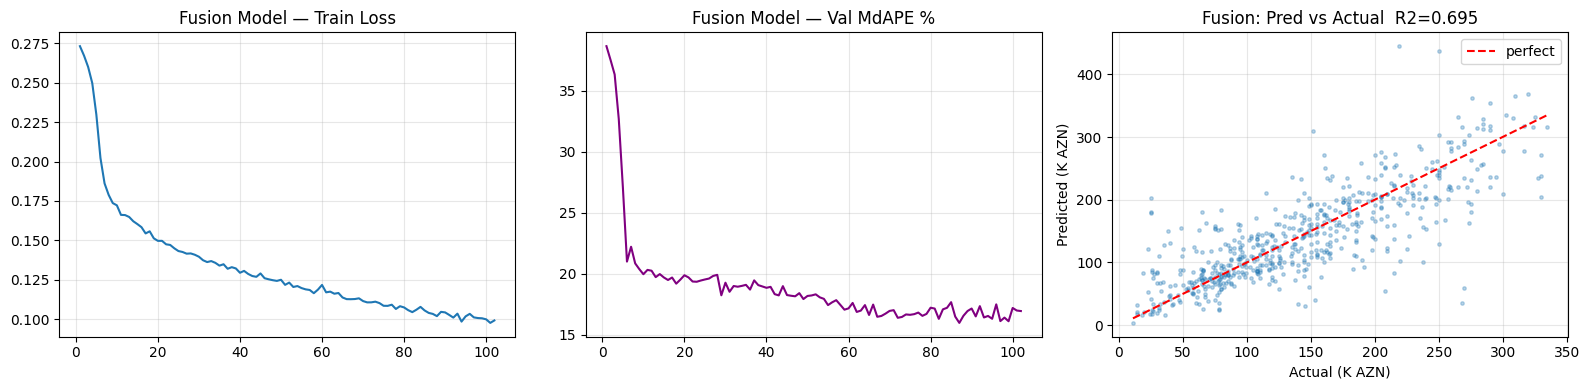

In [22]:
# ── Plots ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

eps = range(1, len(history_mm['loss']) + 1)
axes[0].plot(eps, history_mm['loss'])
axes[0].set_title('Fusion Model — Train Loss'); axes[0].grid(alpha=0.3)

axes[1].plot(eps, history_mm['val_mdape'], color='purple')
axes[1].set_title('Fusion Model — Val MdAPE %'); axes[1].grid(alpha=0.3)

cap  = np.percentile(mm_targets_test, 95)
mask = mm_targets_test < cap
axes[2].scatter(mm_targets_test[mask]/1000, mm_preds_test[mask]/1000, alpha=0.3, s=6)
mn, mx = mm_targets_test[mask].min()/1000, mm_targets_test[mask].max()/1000
axes[2].plot([mn, mx], [mn, mx], 'r--', label='perfect')
axes[2].set_title(f'Fusion: Pred vs Actual  R2={r2_score(mm_targets_test, mm_preds_test):.3f}')
axes[2].set_xlabel('Actual (K AZN)'); axes[2].set_ylabel('Predicted (K AZN)')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'multimodal_results.png', dpi=120)
plt.show()

In [23]:
# ── Save everything ────────────────────────────────────────────────────────
torch.save({
    'fusion_model_state' : mm_model.state_dict(),
    'img_model_state'    : img_model.state_dict(),
    'scaler_mean'        : scaler.mean_,
    'scaler_scale'       : scaler.scale_,
    'tab_features'       : TAB_FEATURES,
    'y_mean'             : Y_MEAN,
    'y_std'              : Y_STD,
    'blend_alpha'        : best_alpha,
    'clip_dim'           : CLIP_DIM,
    'n_tab'              : N_TAB,
}, OUTPUT_DIR / 'multimodal_model.pt')
print('All models saved to', OUTPUT_DIR)

All models saved to ..\models\multimodal


In [86]:
# -- Save upgraded artifacts --------------------------------------------------
upgraded_payload = {
    'best_stage1_method': best_blend_method,
    'best_stage1_scores': blend_scorebook[best_blend_method],
    'best_overall_name': best_model_name,
    'advanced_results': advanced_results,
    'tab_features': TAB_FEATURES,
    'y_mean': Y_MEAN,
    'y_std': Y_STD,
    'n_tab': N_TAB,
    'clip_dim': CLIP_DIM,
    'loc_encoded_file': str(LOC_ENCODED) if 'LOC_ENCODED' in globals() else None,
    'residual_model_state': res_model.state_dict(),
}

if 'TAB_FEATURES' in globals():
    upgraded_payload['tab_feature_count'] = len(TAB_FEATURES)
    upgraded_payload['loc_v6_feature_count'] = len([c for c in TAB_FEATURES if c.endswith('_v6')])

if 'stage1pppppp_status' in globals():
    upgraded_payload['strict_tail_status'] = stage1pppppp_status
    upgraded_payload['strict_tail_active_name'] = stage1pppppp_active_name
    upgraded_payload['strict_tail_metrics'] = stage1pppppp_active_metrics

if 'stage1ppppppp_status' in globals():
    upgraded_payload['strict_dev_selected_status'] = stage1ppppppp_status
    upgraded_payload['strict_dev_selected_active_name'] = stage1ppppppp_active_name
    upgraded_payload['strict_dev_selected_metrics'] = stage1ppppppp_active_metrics

torch.save(upgraded_payload, OUTPUT_DIR / 'multimodal_model_upgraded.pt')
print('Upgraded artifacts saved to', OUTPUT_DIR / 'multimodal_model_upgraded.pt')

Upgraded artifacts saved to ..\models\multimodal\multimodal_model_upgraded.pt


## 6. Predict for a New House

Given a `house_id` (or folder + tabular row), run both modalities and fuse.

In [ ]:
def predict_multimodal(row_df):
    """
    row_df: single-row DataFrame with all tabular features + 'house_id' + 'img_paths'
    """
    # Image embedding
    hid = int(row_df['house_id'].values[0])
    if hid in embeddings:
        emb = embeddings[hid]
    else:
        emb = embed_house(row_df['img_paths'].values[0])

    # Tabular features
    tab_raw  = row_df[TAB_FEATURES].values.astype(np.float32)
    tab_norm = scaler.transform(tab_raw)

    # Stage 2: Fusion MLP
    mm_model.eval()
    with torch.no_grad():
        emb_t = emb.unsqueeze(0).to(device)
        tab_t = torch.tensor(tab_norm, dtype=torch.float32).to(device)
        pred_norm = mm_model(emb_t, tab_t).item()

    price = float(to_price(np.array([pred_norm]))[0])
    print(f'Fusion model estimate: {price:,.0f} AZN')
    return price


# Demo on first test house
demo_row = test_df.iloc[[0]]
print(f'Actual price   : {demo_row[PRICE_COL].values[0]:,.0f} AZN')
predict_multimodal(demo_row)